Saved: 'visualizations_v7\bio_papers.png'


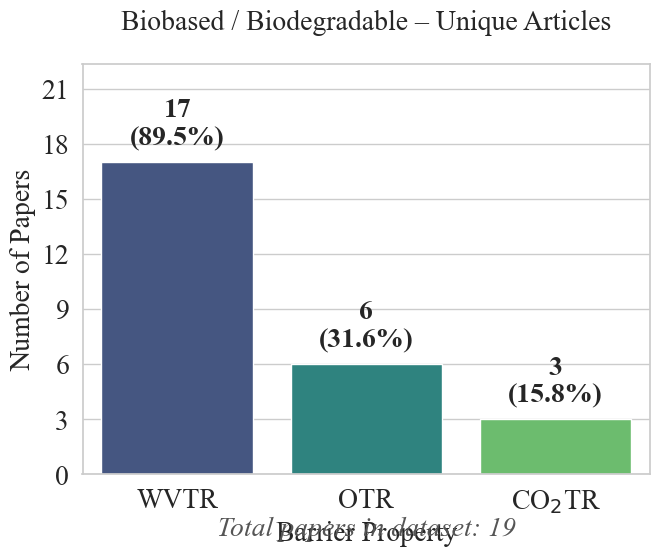

Saved: 'visualizations_v7\bio_measurements.png'


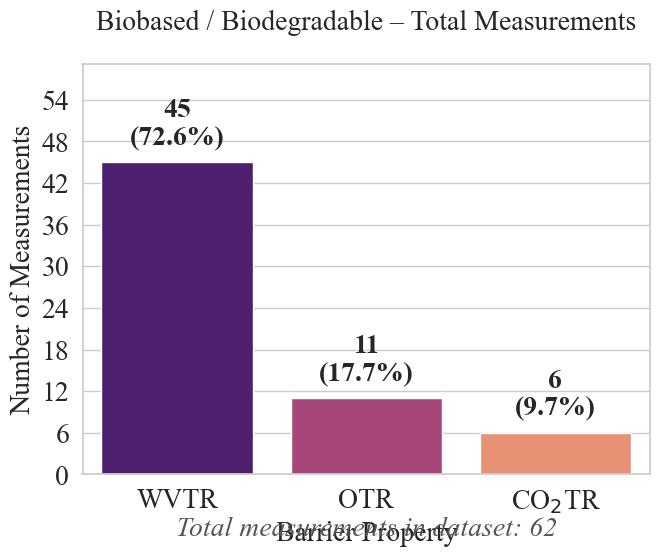

Saved: 'visualizations_v7\reference_papers.png'


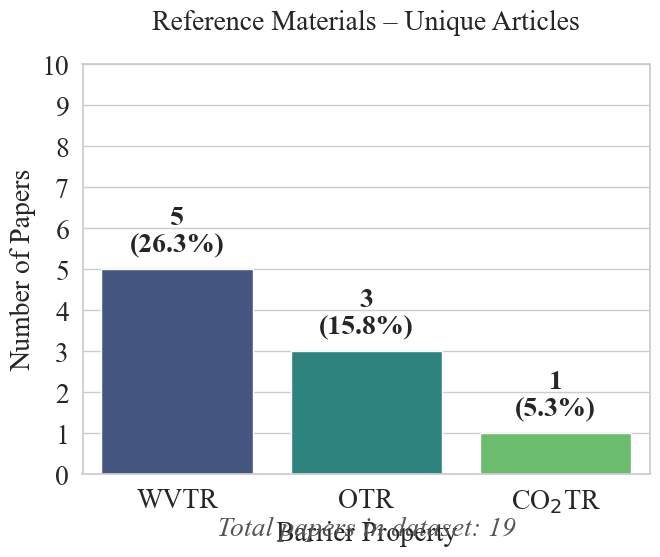

Saved: 'visualizations_v7\reference_measurements.png'


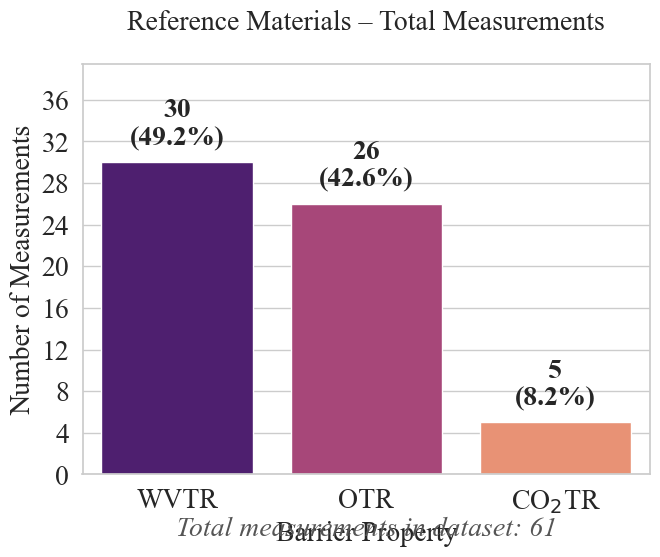

Saved: 'visualizations_v7\bio_papers.png'


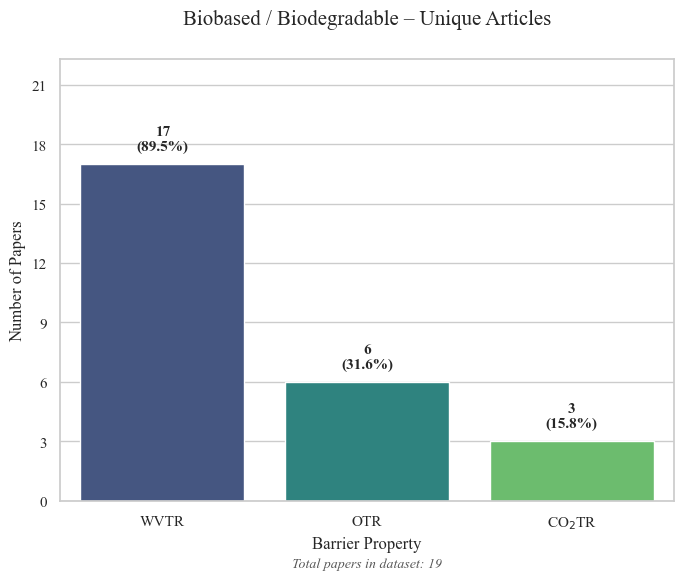

Saved: 'visualizations_v7\bio_measurements.png'


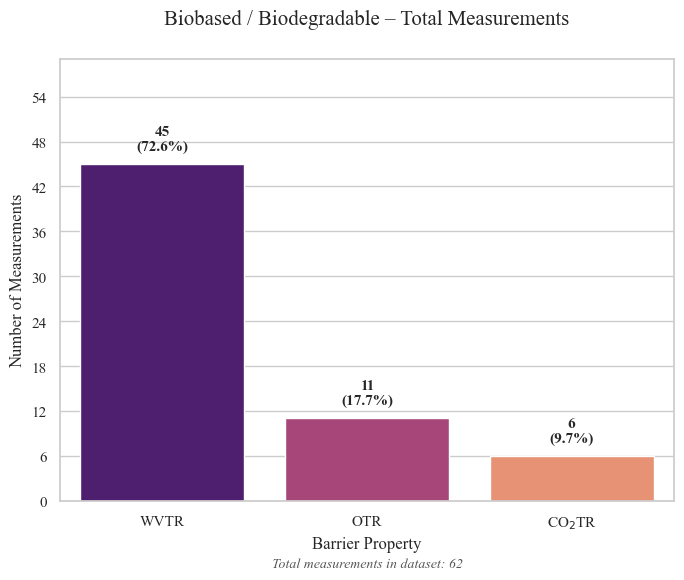

Saved: 'visualizations_v7\reference_papers.png'


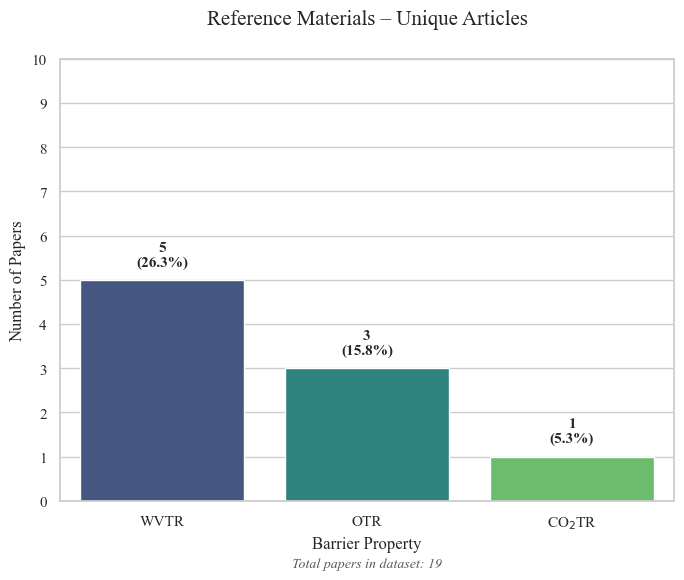

Saved: 'visualizations_v7\reference_measurements.png'


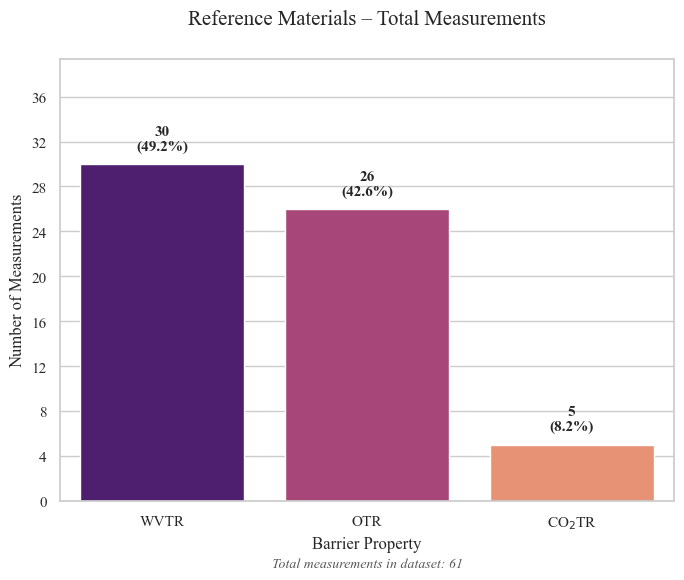

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# 1. Load & filter
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

# 2. Font
plt.rcParams['font.family'] = 'Times New Roman'

# 3. Columns
meas_cols = {
    'OTR':      'OTR100_cm3·m-2·d-1·bar-1',
    'CO$_2$TR': 'CO2TR100_cm3·m-2·d-1·bar-1',
    'WVTR':     'WVTR100_g·m-2·d-1 ',
}
ref_cols = {
    'OTR':      'Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
    'CO$_2$TR': 'Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
    'WVTR':     'Reference_WVTR100_g·m-2·d-1 ',
}

total_papers           = df['Article_ID'].nunique()
total_bio_measurements = sum(int(df[c].notna().sum()) for c in meas_cols.values())
total_ref_measurements = sum(int(df[c].notna().sum()) for c in ref_cols.values())

# 4. Stats
bio_paper_series   = pd.Series({l: df[df[meas_cols[l]].notna()]['Article_ID'].nunique() for l in meas_cols}).sort_values(ascending=False)
bio_measure_series = pd.Series({l: int(df[meas_cols[l]].notna().sum()) for l in meas_cols}).sort_values(ascending=False)
ref_paper_series   = pd.Series({l: df[df[ref_cols[l]].notna()]['Article_ID'].nunique() for l in ref_cols}).sort_values(ascending=False)
ref_measure_series = pd.Series({l: int(df[ref_cols[l]].notna().sum()) for l in ref_cols}).sort_values(ascending=False)

# 5. Helper
def add_labels(ax, total, total_label):
    for p in ax.patches:
        count = int(p.get_height())
        if count == 0:
            continue
        pct = (count / total) * 100
        ax.annotate(
            f'{count}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom',
            xytext=(0, 8), textcoords='offset points',
            fontsize=11, fontweight='bold'
        )
    ax.set_ylim(0, max(ax.get_ylim()[1] * 1.25, 10))
    ax.text(0.5, -0.15, f'Total {total_label} in dataset: {total}',
            ha='center', transform=ax.transAxes,
            fontsize=10, style='italic', color='#555555')

def save_chart(series, ylabel, title, total, total_label, palette, filename):
    sns.set_theme(style='whitegrid')
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.barplot(x=series.index, y=series.values, ax=ax,
                palette=palette, hue=series.index, legend=False)
    ax.set_title(title, fontsize=15, pad=25)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Barrier Property', fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    add_labels(ax, total, total_label)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: '{filename}'")
    plt.show()

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

# ── 4 losse figuren ───────────────────────────────────────────────────
save_chart(
    bio_paper_series, 'Number of Papers',
    'Biobased / Biodegradable – Unique Articles',
    total_papers, 'papers', 'viridis',
    os.path.join(output_folder, 'bio_papers.png')
)

save_chart(
    bio_measure_series, 'Number of Measurements',
    'Biobased / Biodegradable – Total Measurements',
    total_bio_measurements, 'measurements', 'magma',
    os.path.join(output_folder, 'bio_measurements.png')
)

save_chart(
    ref_paper_series, 'Number of Papers',
    'Reference Materials – Unique Articles',
    total_papers, 'papers', 'viridis',
    os.path.join(output_folder, 'reference_papers.png')
)

save_chart(
    ref_measure_series, 'Number of Measurements',
    'Reference Materials – Total Measurements',
    total_ref_measurements, 'measurements', 'magma',
    os.path.join(output_folder, 'reference_measurements.png')
)

Saved as 'visualizations_v7\consolidated_condition_landscape.png'.


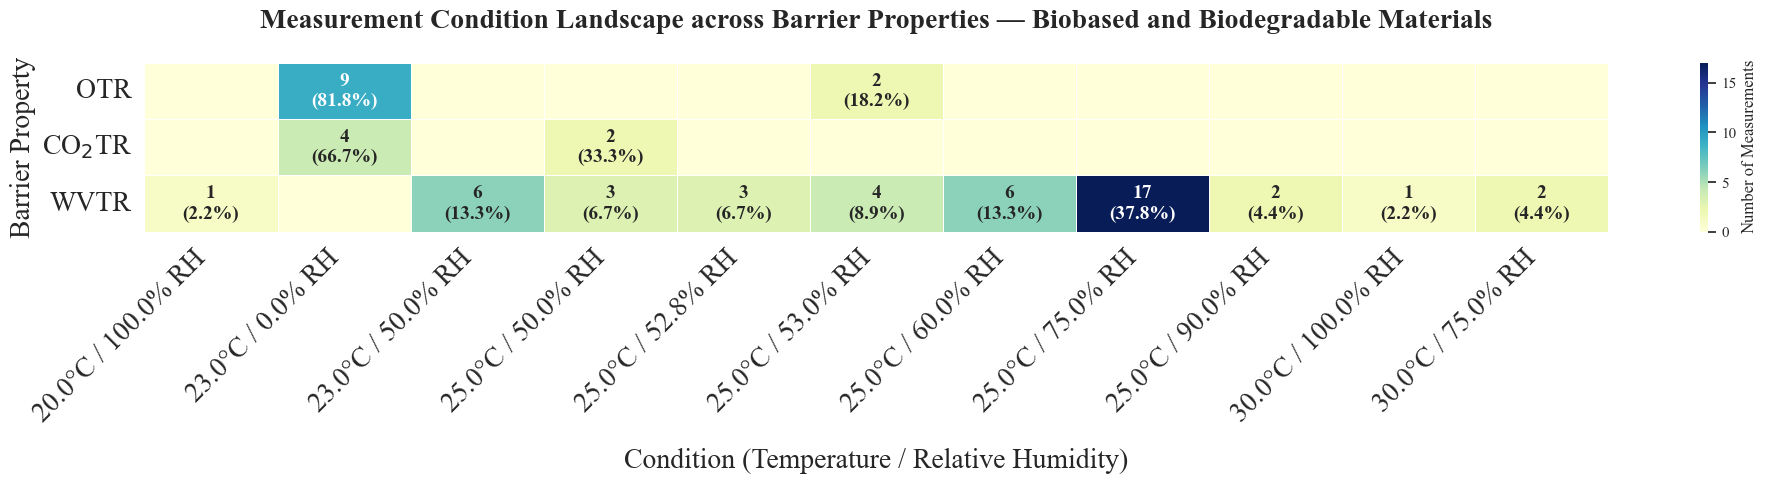

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Load & filter
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

plt.rcParams['font.family'] = 'Times New Roman'

# 2. Prepare data
prop_cols = {
    'OTR':   {'val': 'OTR100_cm3·m-2·d-1·bar-1',   't': 'OTR_temperature_°C',   'rh': 'OTR_RH_%'},
    'CO$_2$TR': {'val': 'CO2TR100_cm3·m-2·d-1·bar-1','t': 'CO2TR_temperature_°C', 'rh': 'CO2TR_RH_%'},
    'WVTR':  {'val': 'WVTR100_g·m-2·d-1 ',          't': 'WVTR_temperature_°C',  'rh': 'WVTR_RH_%'},
}

landscape_data = []
for prop, cols in prop_cols.items():
    temp_df = df[df[cols['val']].notna()].copy()
    temp_df['Condition'] = (
        temp_df[cols['t']].astype(str) + '°C / ' +
        temp_df[cols['rh']].astype(str) + '% RH'
    )
    temp_df = temp_df[~temp_df['Condition'].str.contains('nan')]

    counts = temp_df.groupby('Condition').agg(
        Count=('Article_ID', 'count'),
        Papers=('Article_ID', 'nunique')
    ).reset_index()

    total_prop_m = counts['Count'].sum()
    counts['Percentage'] = (counts['Count'] / total_prop_m) * 100
    counts['Property'] = prop
    landscape_data.append(counts)

summary_df = pd.concat(landscape_data)

# 3. Pivot
pivot_counts = summary_df.pivot(index='Property', columns='Condition', values='Count').fillna(0)
pivot_perc   = summary_df.pivot(index='Property', columns='Condition', values='Percentage').fillna(0)

pivot_counts = pivot_counts.reindex(['OTR', 'CO$_2$TR', 'WVTR'])
pivot_perc   = pivot_perc.reindex(['OTR', 'CO$_2$TR', 'WVTR'])

# 4. Annotation matrix
annot_matrix = []
for i in range(len(pivot_counts)):
    row = []
    for j in range(len(pivot_counts.columns)):
        count = pivot_counts.iloc[i, j]
        perc  = pivot_perc.iloc[i, j]
        row.append(f"{int(count)}\n({perc:.1f}%)" if count > 0 else "")
    annot_matrix.append(row)

# 5. Plot
plt.figure(figsize=(20, 5))
sns.set_theme(style='white')
plt.rcParams['font.family'] = 'Times New Roman'

ax = sns.heatmap(
    pivot_counts,
    annot=np.array(annot_matrix),
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Measurements'},
    annot_kws={'size': 14, 'weight': 'bold'}  # was 10
)

plt.title('Measurement Condition Landscape across Barrier Properties — Biobased and Biodegradable Materials',
          fontsize=20, pad=25, fontweight='bold')  # was 16
plt.xlabel('Condition (Temperature / Relative Humidity)', fontsize=20, labelpad=15)  # was 12
plt.ylabel('Barrier Property', fontsize=20)  # was 12
plt.xticks(rotation=45, ha='right', fontsize=20)  # was default
plt.yticks(rotation=0, fontsize=20)  # was default
plt.tight_layout()

# 6. Save
output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)
save_path = os.path.join(output_folder, 'consolidated_condition_landscape.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved as '{save_path}'.")
plt.show()

Saved as 'visualizations_v7\consolidated_condition_landscape_reference.png'.


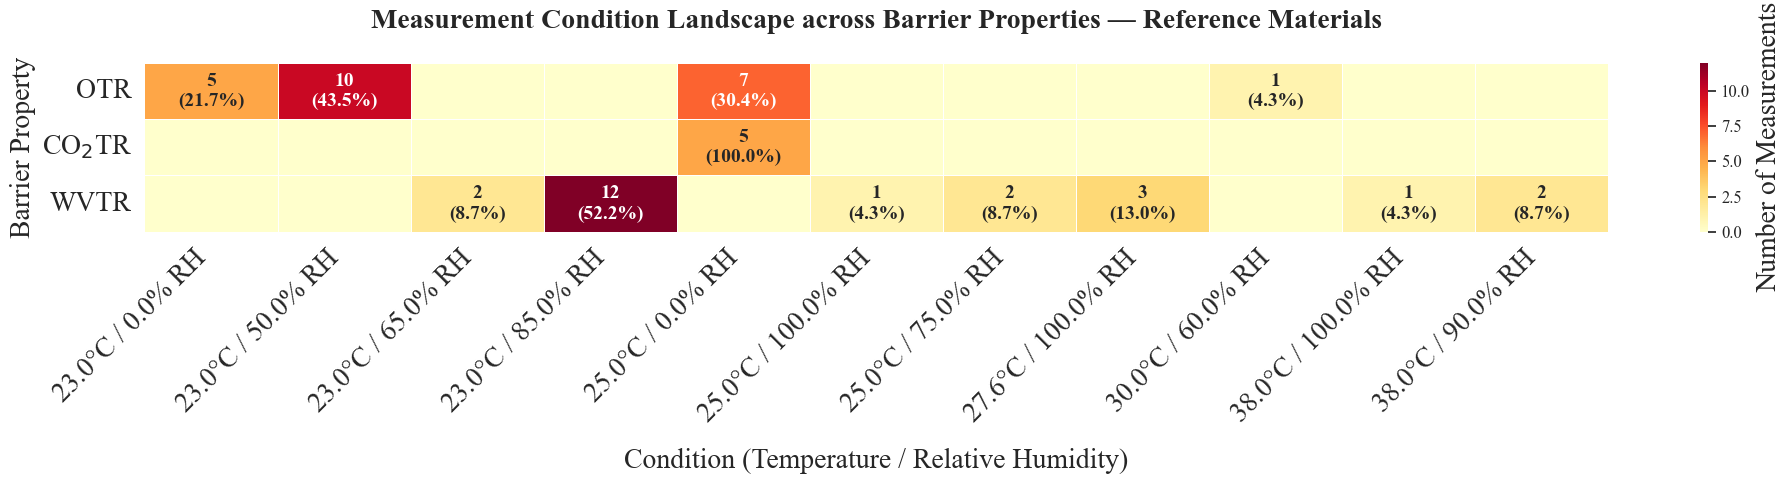

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Load & filter
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

plt.rcParams['font.family'] = 'Times New Roman'

# 2. Prepare data — reference columns
prop_cols = {
    'OTR':      {'val': 'Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',  't': 'Reference_OTR_temperature°C',  'rh': 'Reference_OTR_RH_%'},
    'CO$_2$TR': {'val': 'Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ', 't': 'Reference_COTR_temperature°C', 'rh': 'Reference_COTR_RH_%'},
    'WVTR':     {'val': 'Reference_WVTR100_g·m-2·d-1 ',           't': 'Reference_WVTR_T_°C',          'rh': 'Reference_WVTR_RH_%'},
}

landscape_data = []
for prop, cols in prop_cols.items():
    temp_df = df[df[cols['val']].notna()].copy()
    temp_df['Condition'] = (
        temp_df[cols['t']].astype(str) + '°C / ' +
        temp_df[cols['rh']].astype(str) + '% RH'
    )
    temp_df = temp_df[~temp_df['Condition'].str.contains('nan')]

    counts = temp_df.groupby('Condition').agg(
        Count=('Article_ID', 'count'),
        Papers=('Article_ID', 'nunique')
    ).reset_index()

    total_prop_m = counts['Count'].sum()
    counts['Percentage'] = (counts['Count'] / total_prop_m) * 100
    counts['Property'] = prop
    landscape_data.append(counts)

summary_df = pd.concat(landscape_data)

# 3. Pivot
pivot_counts = summary_df.pivot(index='Property', columns='Condition', values='Count').fillna(0)
pivot_perc   = summary_df.pivot(index='Property', columns='Condition', values='Percentage').fillna(0)

pivot_counts = pivot_counts.reindex(['OTR', 'CO$_2$TR', 'WVTR'])
pivot_perc   = pivot_perc.reindex(['OTR', 'CO$_2$TR', 'WVTR'])

# 4. Annotation matrix
annot_matrix = []
for i in range(len(pivot_counts)):
    row = []
    for j in range(len(pivot_counts.columns)):
        count = pivot_counts.iloc[i, j]
        perc  = pivot_perc.iloc[i, j]
        row.append(f"{int(count)}\n({perc:.1f}%)" if count > 0 else "")
    annot_matrix.append(row)

# 5. Plot
plt.figure(figsize=(20, 5))
sns.set_theme(style='white')
plt.rcParams['font.family'] = 'Times New Roman'

ax = sns.heatmap(
    pivot_counts,
    annot=np.array(annot_matrix),
    fmt='',
    cmap='YlOrRd',   # ander kleurpalet om onderscheid te maken van de biobased heatmap
    linewidths=0.5,
    cbar_kws={'label': 'Number of Measurements'},
    annot_kws={'size': 14, 'weight': 'bold'}
)

ax.collections[0].colorbar.ax.set_ylabel('Number of Measurements', fontsize=20)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)

plt.title('Measurement Condition Landscape across Barrier Properties — Reference Materials',
          fontsize=20, pad=25, fontweight='bold')
plt.xlabel('Condition (Temperature / Relative Humidity)', fontsize=20, labelpad=15)
plt.ylabel('Barrier Property', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.tight_layout()

# 6. Save
output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)
save_path = os.path.join(output_folder, 'consolidated_condition_landscape_reference.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved as '{save_path}'.")
plt.show()

In [4]:
import plotly.express as px
import pandas as pd
import os

# Load & filter
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()
bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()

total_papers = bio['Article_ID'].nunique()

sun_df = bio.groupby(['Material_family', 'Polymer_type']).agg(
    paper_count=('Article_ID', 'nunique')
).reset_index()

sun_df['percentage'] = (sun_df['paper_count'] / total_papers) * 100
sun_df['display_label'] = (
    sun_df['Polymer_type'] + '<br>n=' +
    sun_df['paper_count'].astype(str) + ' (' +
    sun_df['percentage'].round(1).astype(str) + '%)'
)

fig = px.sunburst(
    sun_df,
    path=['Material_family', 'display_label'],
    values='paper_count',
    color='Material_family',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Distribution of Biobased and Biodegradable Polymers'
)

fig.update_traces(
    textinfo='label',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b>'
)
fig.update_layout(
    margin=dict(t=80, l=20, r=20, b=20),
    font=dict(size=14, family='Times New Roman'),
    title_font=dict(size=20, family='Times New Roman'),
    paper_bgcolor='white'
)

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)
fig.write_html(os.path.join(output_folder, 'sunburst_biobased.html'))
fig.show()

In [5]:
import plotly.express as px
import pandas as pd
import os

# Load & filter
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)


# ── Figuur 1: Biobased / Biodegradable ───────────────────────────────
bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()
total_bio = bio['Article_ID'].nunique()

sun_bio = bio.groupby(['Material_family', 'Polymer_type']).agg(
    paper_count=('Article_ID', 'nunique')
).reset_index()

sun_bio['percentage'] = (sun_bio['paper_count'] / total_bio) * 100
sun_bio['display_label'] = (
    sun_bio['Polymer_type'] + '<br>n=' +
    sun_bio['paper_count'].astype(str) + ' (' +
    sun_bio['percentage'].round(1).astype(str) + '%)'
)

fig1 = px.sunburst(
    sun_bio,
    path=['Material_family', 'display_label'],
    values='paper_count',
    color='Material_family',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Distribution of Biobased and Biodegradable Polymers'
)
fig1.update_traces(
    textinfo='label',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b>'
)
fig1.update_layout(
    margin=dict(t=80, l=20, r=20, b=20),
    font=dict(size=14, family='Times New Roman'),
    title_font=dict(size=20, family='Times New Roman'),
    title_x=0.5,
    paper_bgcolor='white'
)
fig1.write_html(os.path.join(output_folder, 'sunburst_biobased.html'))
fig1.show()


# ── Figuur 2: Reference materials ────────────────────────────────────
ref = df[df['Reference_polymer'].notna()].copy()
total_ref = ref['Article_ID'].nunique()

sun_ref = ref.groupby(['Reference_polymer_family', 'Reference_polymer']).agg(
    paper_count=('Article_ID', 'nunique')
).reset_index()

sun_ref['percentage'] = (sun_ref['paper_count'] / total_ref) * 100
sun_ref['display_label'] = (
    sun_ref['Reference_polymer'] + '<br>n=' +
    sun_ref['paper_count'].astype(str) + ' (' +
    sun_ref['percentage'].round(1).astype(str) + '%)'
)

fig2 = px.sunburst(
    sun_ref,
    path=['Reference_polymer_family', 'display_label'],
    values='paper_count',
    color='Reference_polymer_family',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Distribution of Reference Polymers'
)
fig2.update_traces(
    textinfo='label',
    insidetextorientation='radial',
    hovertemplate='<b>%{label}</b>'
)
fig2.update_layout(
    margin=dict(t=80, l=20, r=20, b=20),
    font=dict(size=14, family='Times New Roman'),
    title_font=dict(size=20, family='Times New Roman'),
    title_x=0.5,
    paper_bgcolor='white'
)
fig2.write_html(os.path.join(output_folder, 'sunburst_reference.html'))
fig2.show()
    


Saved: scatter_WVTR.png


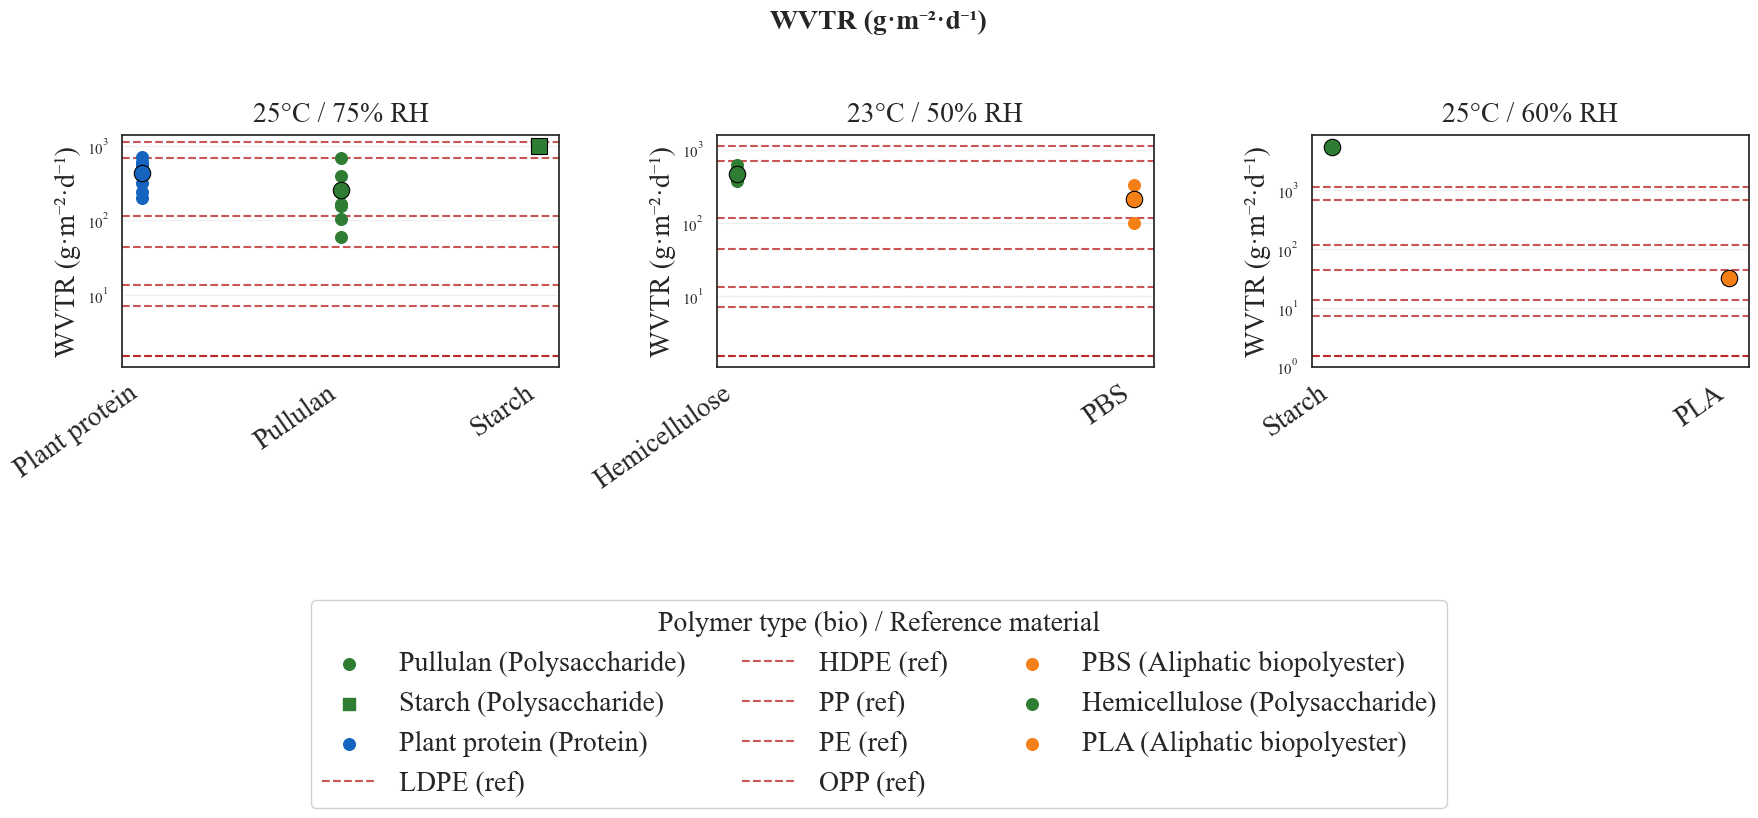

Saved: scatter_OTR.png


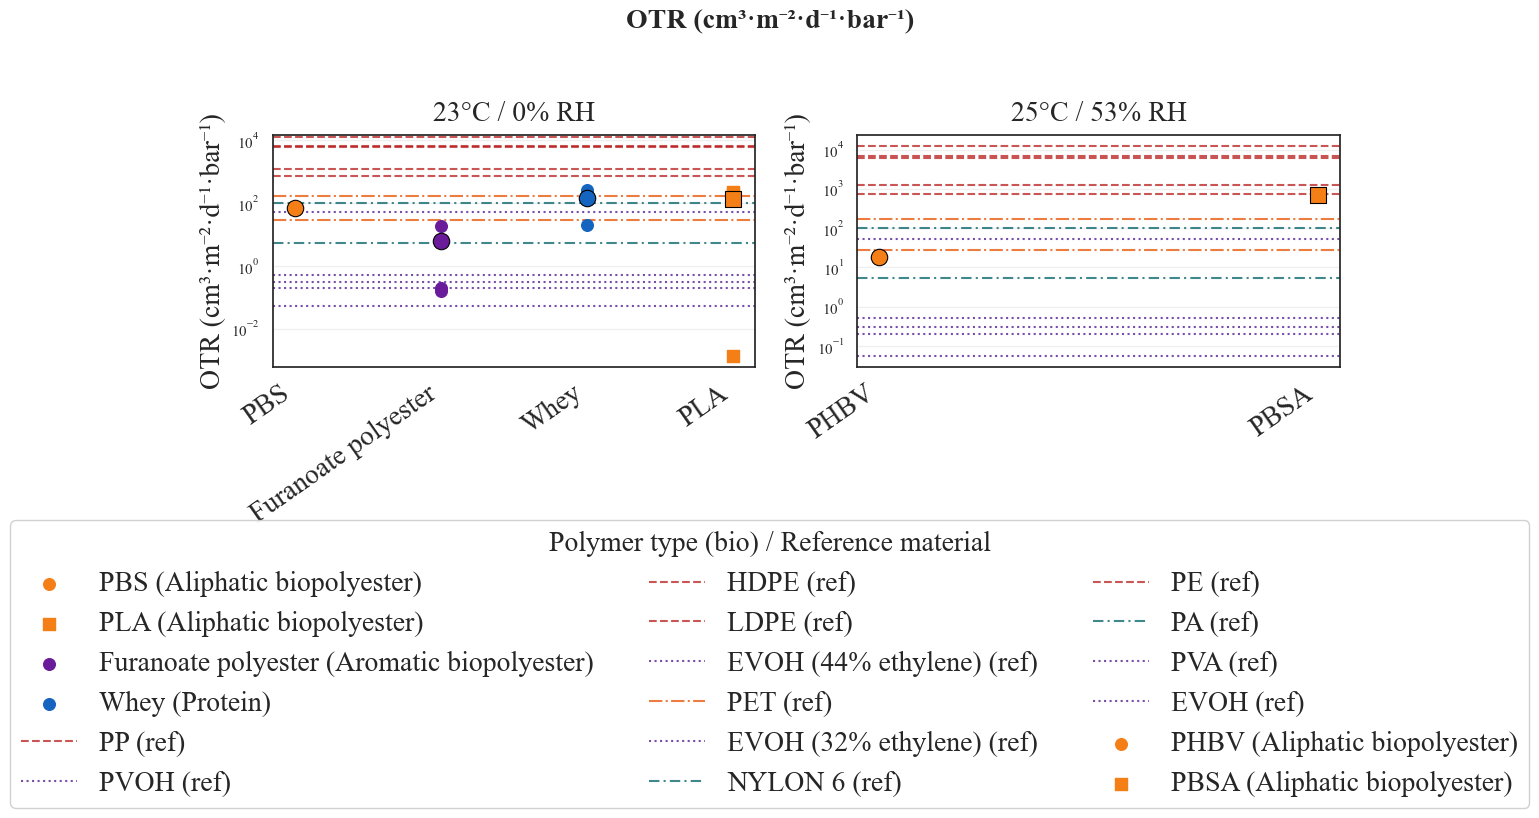

Saved: scatter_CO2TR.png


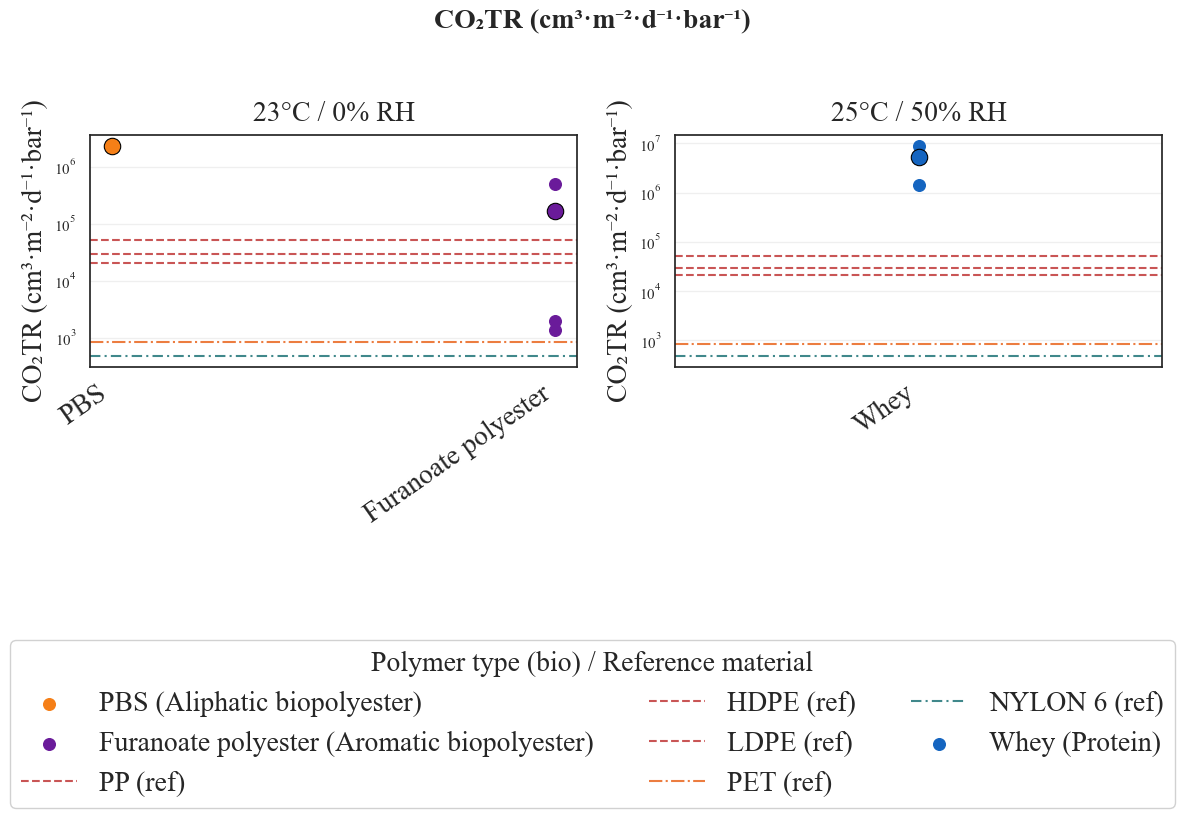

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Load & filter ─────────────────────────────────────────────────────
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()
ref = df[df['Reference_polymer'].notna()].copy()

plt.rcParams['font.family'] = 'Times New Roman'

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────
PROPS = [
    dict(
        label='WVTR',
        unit='g·m⁻²·d⁻¹',
        bio_val='WVTR100_g·m-2·d-1 ',
        bio_t='WVTR_temperature_°C',
        bio_rh='WVTR_RH_%',
        ref_val='Reference_WVTR100_g·m-2·d-1 ',
        ref_t='Reference_WVTR_T_°C',
        ref_rh='Reference_WVTR_RH_%',
        top_n=3,
    ),
    dict(
        label='OTR',
        unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='OTR100_cm3·m-2·d-1·bar-1',
        bio_t='OTR_temperature_°C',
        bio_rh='OTR_RH_%',
        ref_val='Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_OTR_temperature°C',
        ref_rh='Reference_OTR_RH_%',
        top_n=2,
    ),
    dict(
        label='CO₂TR',
        unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='CO2TR100_cm3·m-2·d-1·bar-1',
        bio_t='CO2TR_temperature_°C',
        bio_rh='CO2TR_RH_%',
        ref_val='Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_COTR_temperature°C',
        ref_rh='Reference_COTR_RH_%',
        top_n=2,
    ),
]

FAMILY_COLORS = {
    'Polysaccharide':         '#2E7D32',
    'Protein':                '#1565C0',
    'Aliphatic biopolyester': '#F57F17',
    'Aromatic biopolyester':  '#6A1B9A',
    'Vinyl biopolymer':       '#00838F',
}

REF_STYLES = {
    'Polyolefin':         dict(color='#B71C1C', ls='--',          lw=1.5),
    'Aromatic polyester': dict(color='#E65100', ls='-.',           lw=1.5),
    'Vinyl polymer':      dict(color='#4A148C', ls=':',            lw=1.5),
    'Polyamide':          dict(color='#006064', ls=(0,(5,2,1,2)), lw=1.5),
    'Polystyrene':        dict(color='#827717', ls='--',           lw=1.5),
}

MARKER_STYLES = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']


def condition_label(t, rh):
    t_s  = str(int(t))  if t  == int(t)  else str(t)
    rh_s = str(int(rh)) if rh == int(rh) else str(rh)
    return f"{t_s}°C / {rh_s}% RH"


# ── One figure per property ───────────────────────────────────────────
for prop in PROPS:
    bio_sub = bio[[prop['bio_val'], prop['bio_t'], prop['bio_rh'],
                   'Polymer_type', 'Material_family']].dropna()

    # Top N conditions by count
    top_conditions = (
        bio_sub.groupby([prop['bio_t'], prop['bio_rh']])
        .size().sort_values(ascending=False)
        .head(prop['top_n'])
        .index.tolist()
    )

    bio_rh_values = set(rh for _, rh in top_conditions)

    n_cond = len(top_conditions)
    fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 7), sharey=False)
    if n_cond == 1:
        axes = [axes]

    fig.suptitle(f'{prop["label"]} ({prop["unit"]})',
                 fontsize=20, fontweight='bold', y=1.01)

    for ax, (t_val, rh_val) in zip(axes, top_conditions):
        cond_label = condition_label(t_val, rh_val)

        # ── Bio data ─────────────────────────────────────────────────
        mask   = (bio_sub[prop['bio_t']] == t_val) & (bio_sub[prop['bio_rh']] == rh_val)
        cond_df = bio_sub[mask].copy()

        polymers    = cond_df['Polymer_type'].unique()
        x_positions = {p: i for i, p in enumerate(polymers)}

        for fam, fam_df in cond_df.groupby('Material_family'):
            color  = FAMILY_COLORS.get(fam, 'grey')
            ptypes = fam_df['Polymer_type'].unique()
            for j, ptype in enumerate(ptypes):
                marker = MARKER_STYLES[j % len(MARKER_STYLES)]
                vals   = fam_df[fam_df['Polymer_type'] == ptype][prop['bio_val']]
                x      = x_positions[ptype]
                ax.scatter(
                    [x] * len(vals), vals,
                    color=color, marker=marker, s=70, zorder=3,
                    label=f'{ptype} ({fam})'
                )
                ax.scatter(x, vals.mean(), color=color, marker=marker,
                           s=140, edgecolors='black', linewidths=0.8,
                           zorder=4)

        ax.set_xticks(range(len(polymers)))
        ax.set_xticklabels(polymers, rotation=35, ha='right', fontsize=20)
        ax.set_ylabel(f'{prop["label"]} ({prop["unit"]})', fontsize=20)
        ax.set_title(cond_label, fontsize=20, pad=10)
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3)

        # ── Reference lines ───────────────────────────────────────────
        ref_sub = ref[[prop['ref_val'], prop['ref_t'], prop['ref_rh'],
                       'Reference_polymer', 'Reference_polymer_family']].dropna()

        ref_lines_added = set()
        for _, row in ref_sub.iterrows():
            fam = row['Reference_polymer_family']
            pol = row['Reference_polymer']
            val = row[prop['ref_val']]
            rh  = row[prop['ref_rh']]

            if fam != 'Polyolefin' and rh not in bio_rh_values:
                continue

            style = REF_STYLES.get(fam, dict(color='grey', ls='--', lw=1))
            label = f'{pol} (ref)' if pol not in ref_lines_added else None
            ax.axhline(val, label=label, **style, alpha=0.75)
            ref_lines_added.add(pol)

        ax.legend().set_visible(False)

    # ── Legenda buiten het figuur ─────────────────────────────────────
    handles_all, labels_all = {}, {}
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l and l not in labels_all:
                labels_all[l] = h

    fig.legend(
        labels_all.values(), labels_all.keys(),
        fontsize=20,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=True,
        framealpha=0.9,
        title='Polymer type (bio) / Reference material',
        title_fontsize=20
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.5)

    fname = f'scatter_{prop["label"].replace("₂", "2")}.png'
    plt.savefig(os.path.join(output_folder, fname), dpi=300, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()

Saved: scatter_WVTR.png


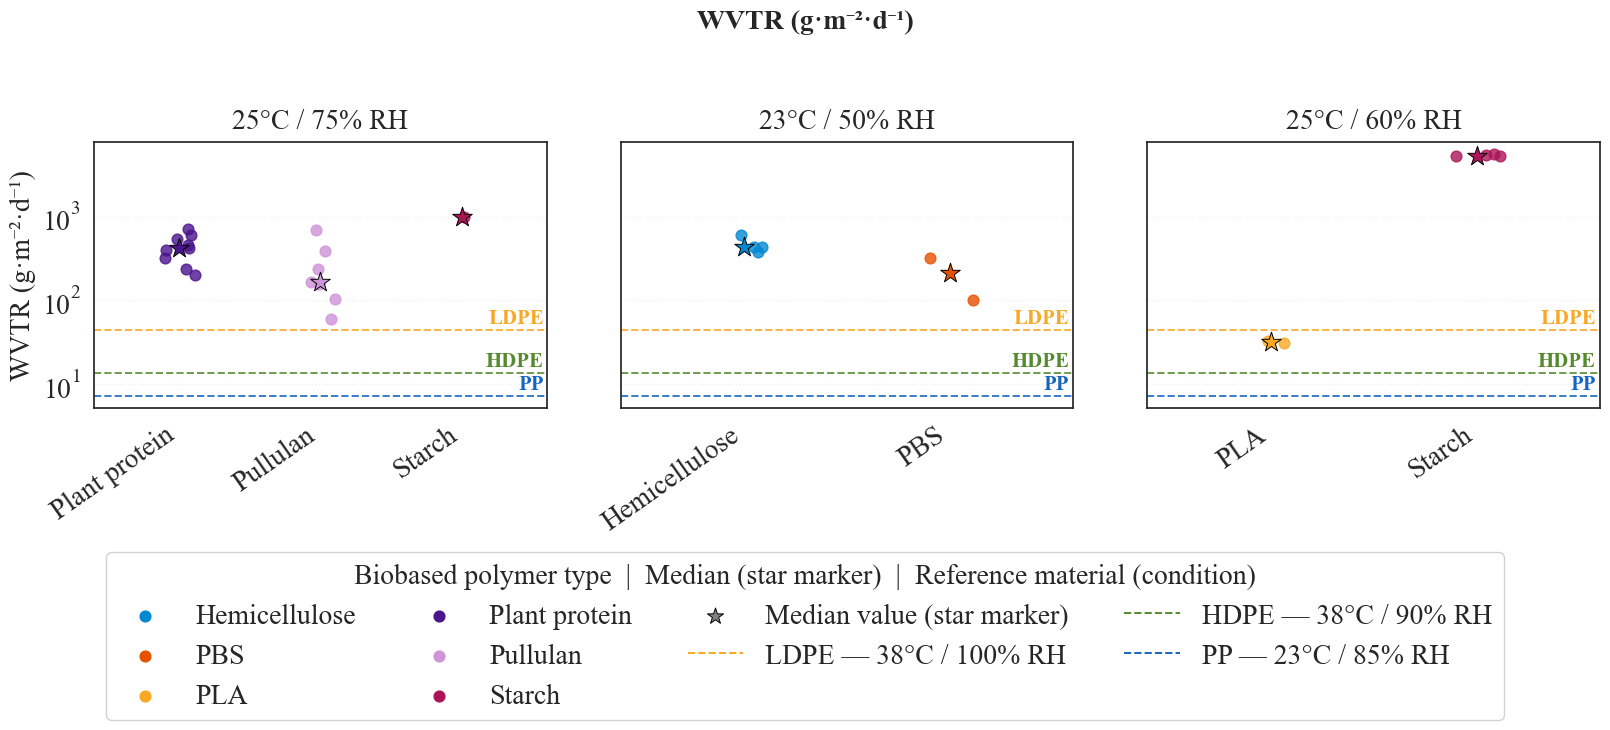

Saved: scatter_OTR.png


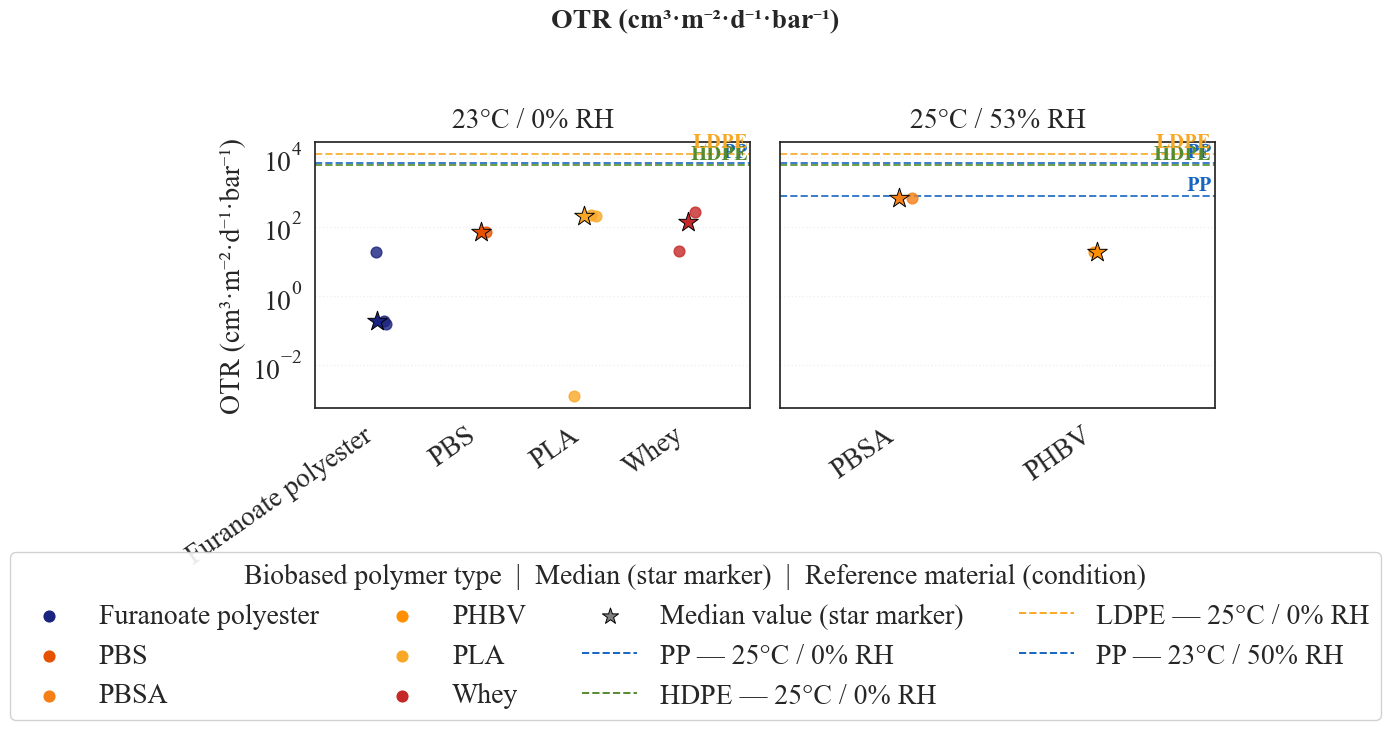

Saved: scatter_CO2TR.png


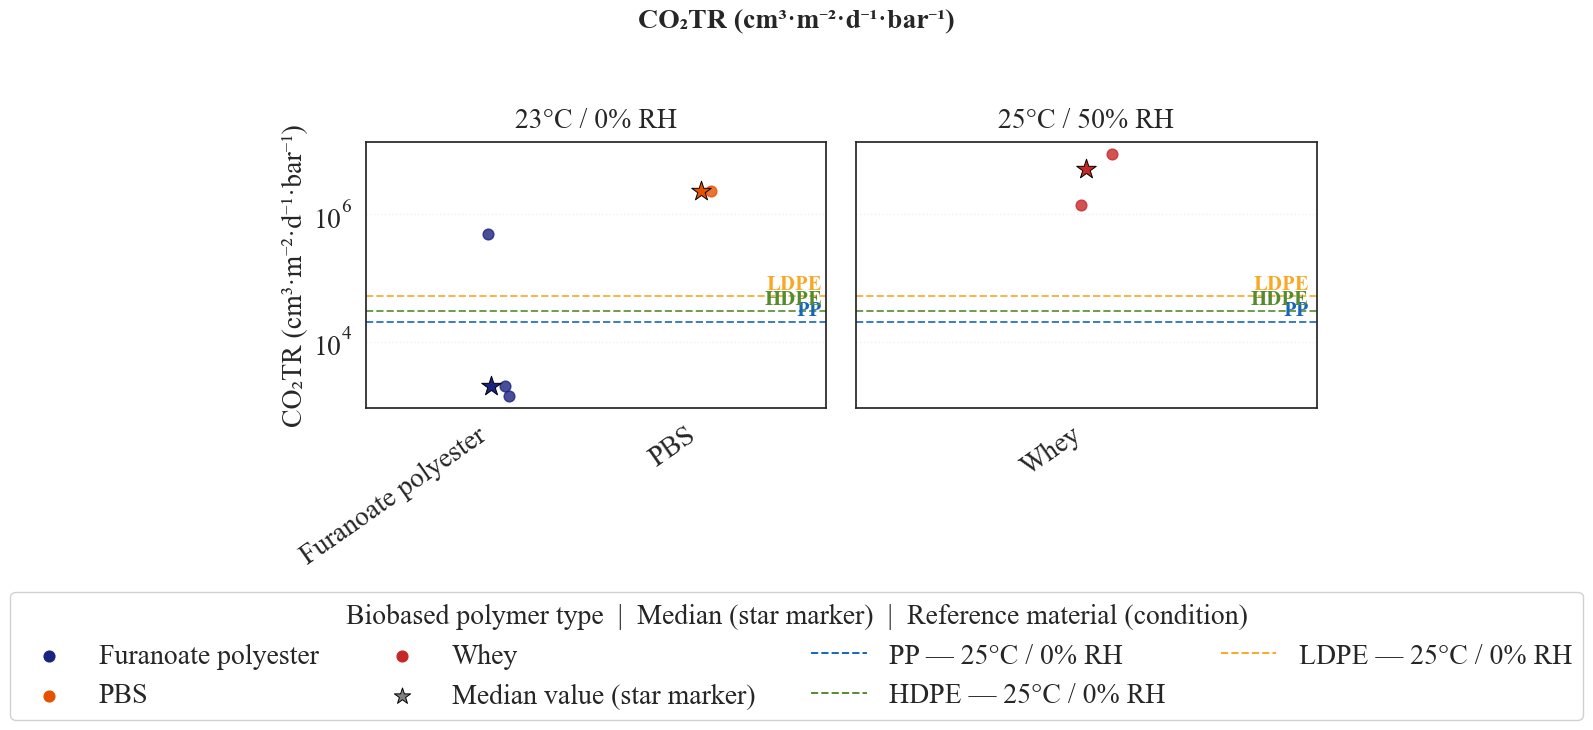

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os

# ── Load & filter ─────────────────────────────────────────────────────
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()

bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()
ref = df[df['Reference_polymer'].notna()].copy()

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 20

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

SELECTED_REFS = ['LDPE', 'HDPE', 'PP']

PROPS = [
    dict(
        label='WVTR', unit='g·m⁻²·d⁻¹',
        bio_val='WVTR100_g·m-2·d-1 ',
        bio_t='WVTR_temperature_°C', bio_rh='WVTR_RH_%',
        ref_val='Reference_WVTR100_g·m-2·d-1 ',
        ref_t='Reference_WVTR_T_°C', ref_rh='Reference_WVTR_RH_%',
        top_n=3,
    ),
    dict(
        label='OTR', unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='OTR100_cm3·m-2·d-1·bar-1',
        bio_t='OTR_temperature_°C', bio_rh='OTR_RH_%',
        ref_val='Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_OTR_temperature°C', ref_rh='Reference_OTR_RH_%',
        top_n=2,
    ),
    dict(
        label='CO₂TR', unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='CO2TR100_cm3·m-2·d-1·bar-1',
        bio_t='CO2TR_temperature_°C', bio_rh='CO2TR_RH_%',
        ref_val='Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_COTR_temperature°C', ref_rh='Reference_COTR_RH_%',
        top_n=2,
    ),
]

POLYMER_COLORS = {
    'Cellulose derivative': '#1B5E20',
    'Chitosan':             '#388E3C',
    'Gelatin':              '#1565C0',
    'Hemicellulose':        '#0288D1',
    'PBS':                  '#E65100',
    'PBSA':                 '#F57F17',
    'PHBV':                 '#FF8F00',
    'PLA':                  '#F9A825',
    'PVA':                  '#00838F',
    'Pectin':               '#006064',
    'Plant protein':        '#4A148C',
    'Pullulan':             '#CE93D8',
    'Starch':               '#AD1457',
    'Whey':                 '#C62828',
    'Furanoate polyester':  '#1A237E',
}

REF_COLORS = {
    'LDPE': '#F9A825',
    'HDPE': '#558B2F',
    'PP':   '#1565C0',
}

def condition_label(t, rh):
    t_s  = str(int(t))  if t  == int(t)  else str(t)
    rh_s = str(int(rh)) if rh == int(rh) else str(rh)
    return f"{t_s}°C / {rh_s}% RH"


for prop in PROPS:
    bio_sub = bio[[prop['bio_val'], prop['bio_t'], prop['bio_rh'],
                   'Polymer_type', 'Material_family']].dropna()

    top_conditions = (
        bio_sub.groupby([prop['bio_t'], prop['bio_rh']])
        .size().sort_values(ascending=False)
        .head(prop['top_n'])
        .index.tolist()
    )

    ref_sub = ref[ref['Reference_polymer'].isin(SELECTED_REFS)][
        [prop['ref_val'], prop['ref_t'], prop['ref_rh'], 'Reference_polymer']
    ].dropna()

    n_cond = len(top_conditions)
    fig, axes = plt.subplots(1, n_cond, figsize=(5.5 * n_cond, 7), sharey=True)
    if n_cond == 1:
        axes = [axes]

    fig.suptitle(f'{prop["label"]} ({prop["unit"]})',
                 fontsize=20, fontweight='bold', y=1.02)

    bio_legend_handles = {}
    ref_legend_handles = {}

    for ax_i, (ax, (t_val, rh_val)) in enumerate(zip(axes, top_conditions)):

        mask    = (bio_sub[prop['bio_t']] == t_val) & (bio_sub[prop['bio_rh']] == rh_val)
        cond_df = bio_sub[mask].copy()

        polymers    = sorted(cond_df['Polymer_type'].unique())
        x_positions = {p: i for i, p in enumerate(polymers)}

        rng = np.random.default_rng(42)

        for ptype in polymers:
            ptype_df = cond_df[cond_df['Polymer_type'] == ptype]
            color    = POLYMER_COLORS.get(ptype, 'grey')
            vals     = ptype_df[prop['bio_val']].values
            x_base   = x_positions[ptype]

            jitter = rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(
                x_base + jitter, vals,
                color=color, marker='o', s=60, zorder=3, alpha=0.8
            )
            ax.scatter(
                x_base, np.median(vals),
                color=color, marker='*', s=220,
                edgecolors='black', linewidths=0.7, zorder=5
            )
            if ptype not in bio_legend_handles:
                bio_legend_handles[ptype] = plt.scatter(
                    [], [], color=color, marker='o', s=60, label=ptype
                )

        ax.set_xticks(range(len(polymers)))
        ax.set_xticklabels(polymers, rotation=35, ha='right', fontsize=20)
        if ax_i == 0:
            ax.set_ylabel(f'{prop["label"]} ({prop["unit"]})', fontsize=20)
        ax.set_title(condition_label(t_val, rh_val), fontsize=20, pad=10)
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        ax.set_xlim(-0.6, len(polymers) - 0.4)
        ax.tick_params(axis='y', labelsize=20)

        plotted_refs = set()
        for _, row in ref_sub.iterrows():
            pol = row['Reference_polymer']
            val = row[prop['ref_val']]
            rh  = row[prop['ref_rh']]
            t   = row[prop['ref_t']]

            if rh != rh_val:
                match_exists = ((ref_sub['Reference_polymer'] == pol) &
                                (ref_sub[prop['ref_rh']] == rh_val)).any()
                if match_exists:
                    continue

            color     = REF_COLORS.get(pol, 'grey')
            key       = f'{pol}_{rh}'
            leg_label = f'{pol} — {int(t)}°C / {int(rh)}% RH'
            if key in plotted_refs:
                continue

            ax.axhline(val, color=color, ls='--', lw=1.4, alpha=0.85, zorder=2)
            ax.text(
                len(polymers) - 0.42, val * 1.06,
                pol,
                color=color, fontsize=15, fontweight='bold',
                va='bottom', ha='right'
            )
            plotted_refs.add(key)

            if key not in ref_legend_handles:
                ref_legend_handles[key] = mlines.Line2D(
                    [], [], color=color, ls='--', lw=1.4, label=leg_label
                )

    legend_handles = []
    for ptype, handle in sorted(bio_legend_handles.items()):
        legend_handles.append(handle)
    legend_handles.append(
        plt.scatter([], [], marker='*', color='grey', s=150,
                    edgecolors='black', linewidths=0.7, label='Median value (star marker)')
    )
    for handle in ref_legend_handles.values():
        legend_handles.append(handle)

    fig.legend(
        handles=legend_handles,
        fontsize=20,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.015),
        ncol=4,
        frameon=True,
        framealpha=0.9,
        title='Biobased polymer type  |  Median (star marker)  |  Reference material (condition)',
        title_fontsize=20
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.45)

    fname = f'scatter_{prop["label"].replace("₂", "2")}.png'
    plt.savefig(os.path.join(output_folder, fname), dpi=300, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()

Saved: table_WVTR.png


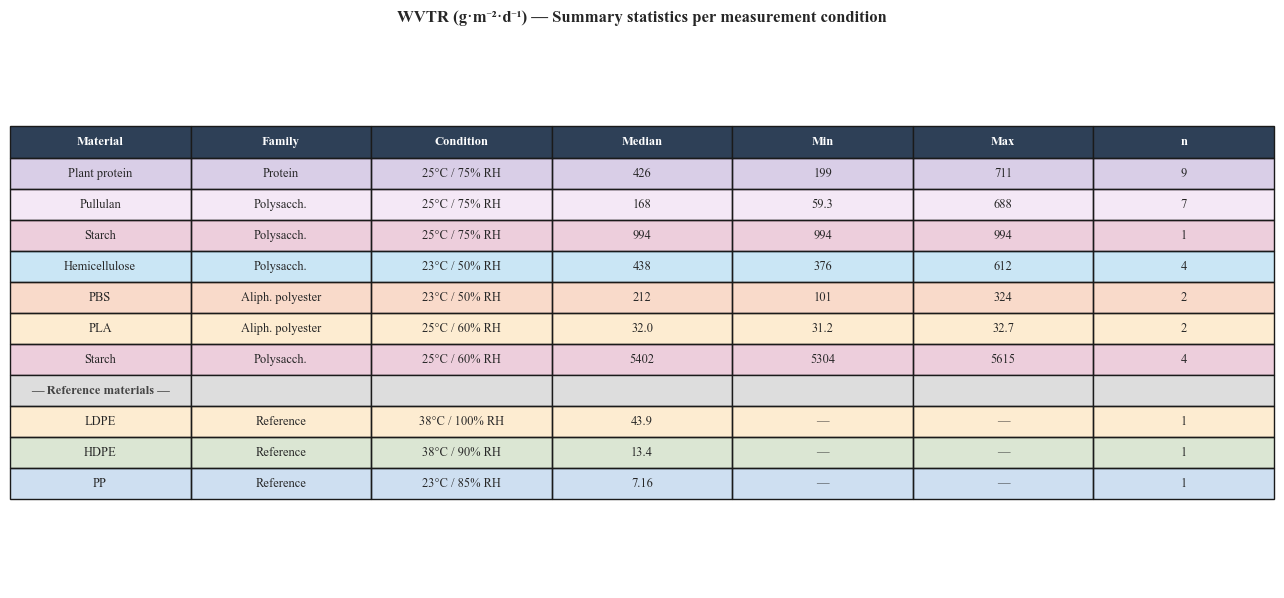

Saved: table_OTR.png


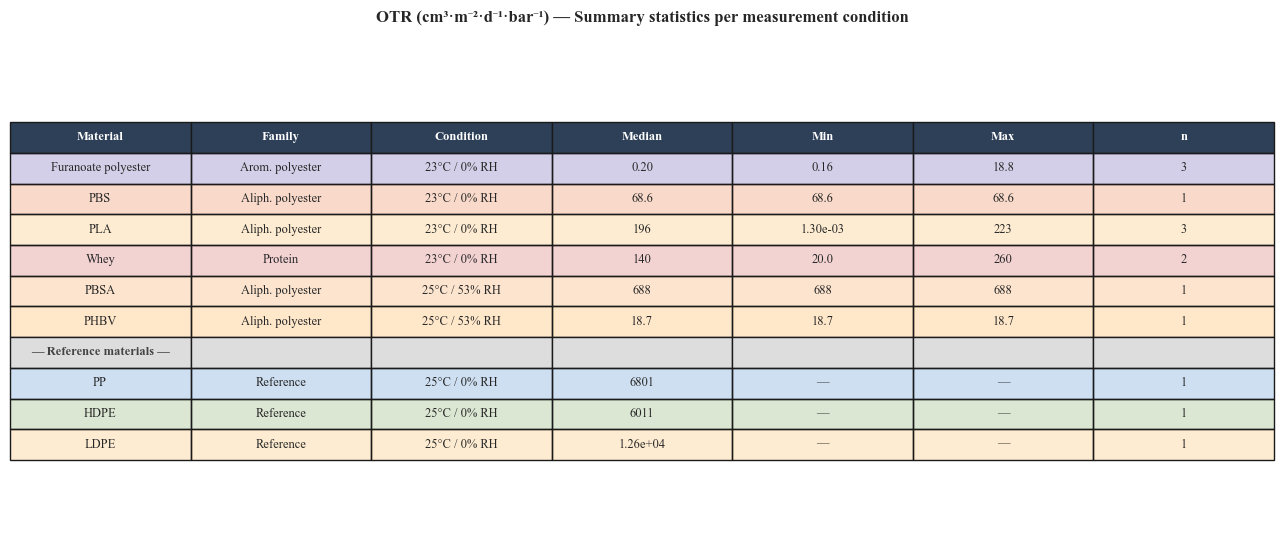

Saved: table_CO2TR.png


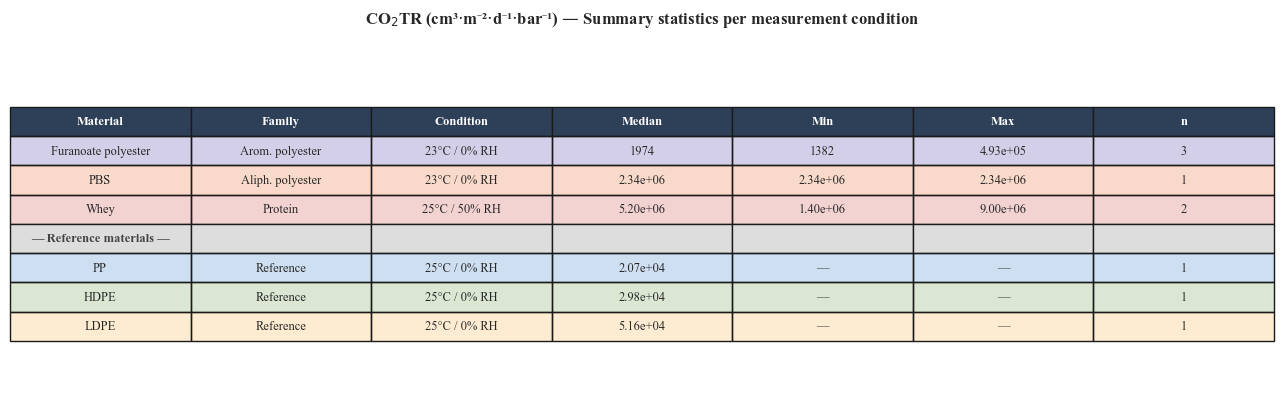

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()
bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()
ref = df[df['Reference_polymer'].notna()].copy()

plt.rcParams['font.family'] = 'Times New Roman'

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

SELECTED_REFS = ['LDPE', 'HDPE', 'PP']

PROPS = [
    dict(
        label='WVTR', unit='g·m⁻²·d⁻¹',
        bio_val='WVTR100_g·m-2·d-1 ',
        bio_t='WVTR_temperature_°C', bio_rh='WVTR_RH_%',
        ref_val='Reference_WVTR100_g·m-2·d-1 ',
        ref_t='Reference_WVTR_T_°C', ref_rh='Reference_WVTR_RH_%',
        top_n=3,
    ),
    dict(
        label='OTR', unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='OTR100_cm3·m-2·d-1·bar-1',
        bio_t='OTR_temperature_°C', bio_rh='OTR_RH_%',
        ref_val='Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_OTR_temperature°C', ref_rh='Reference_OTR_RH_%',
        top_n=2,
    ),
    dict(
        label='CO$_2$TR', unit='cm³·m⁻²·d⁻¹·bar⁻¹',
        bio_val='CO2TR100_cm3·m-2·d-1·bar-1',
        bio_t='CO2TR_temperature_°C', bio_rh='CO2TR_RH_%',
        ref_val='Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹ ',
        ref_t='Reference_COTR_temperature°C', ref_rh='Reference_COTR_RH_%',
        top_n=2,
    ),
]

FAMILY_SHORT = {
    'Polysaccharide':         'Polysacch.',
    'Protein':                'Protein',
    'Aliphatic biopolyester': 'Aliph. polyester',
    'Aromatic biopolyester':  'Arom. polyester',
    'Vinyl biopolymer':       'Vinyl',
}

POLYMER_COLORS = {
    'Cellulose derivative': '#1B5E20',
    'Chitosan':             '#388E3C',
    'Gelatin':              '#1565C0',
    'Hemicellulose':        '#0288D1',
    'PBS':                  '#E65100',
    'PBSA':                 '#F57F17',
    'PHBV':                 '#FF8F00',
    'PLA':                  '#F9A825',
    'PVA':                  '#00838F',
    'Pectin':               '#006064',
    'Plant protein':        '#4A148C',
    'Pullulan':             '#CE93D8',
    'Starch':               '#AD1457',
    'Whey':                 '#C62828',
    'Furanoate polyester':  '#311B92',
}

REF_COLORS = {
    'LDPE': '#F9A825',
    'HDPE': '#558B2F',
    'PP':   '#1565C0',
}

def fmt_val(v):
    if v == 0:                   return '0'
    elif v >= 10000 or v < 0.01: return f'{v:.2e}'
    elif v >= 100:               return f'{v:.0f}'
    elif v >= 10:                return f'{v:.1f}'
    else:                        return f'{v:.2f}'

def condition_label(t, rh):
    t_s  = str(int(t))  if t  == int(t)  else str(t)
    rh_s = str(int(rh)) if rh == int(rh) else str(rh)
    return f"{t_s}°C / {rh_s}% RH"


for prop in PROPS:
    bio_sub = bio[[prop['bio_val'], prop['bio_t'], prop['bio_rh'],
                   'Polymer_type', 'Material_family']].dropna()
    ref_sub = ref[ref['Reference_polymer'].isin(SELECTED_REFS)][
        [prop['ref_val'], prop['ref_t'], prop['ref_rh'], 'Reference_polymer']
    ].dropna()

    top_conditions = (
        bio_sub.groupby([prop['bio_t'], prop['bio_rh']])
        .size().sort_values(ascending=False)
        .head(prop['top_n'])
        .index.tolist()
    )
    bio_rh_values = set(rh for _, rh in top_conditions)

    # ── Bouw tabeldata ────────────────────────────────────────────────
    all_rows   = []
    row_colors = []
    col_labels = ['Material', 'Family', 'Condition', 'Median', 'Min', 'Max', 'n']

    # Biobased rijen
    for t_val, rh_val in top_conditions:
        mask    = (bio_sub[prop['bio_t']] == t_val) & (bio_sub[prop['bio_rh']] == rh_val)
        cond_df = bio_sub[mask].copy()
        cond_str = condition_label(t_val, rh_val)

        for ptype in sorted(cond_df['Polymer_type'].unique()):
            ptype_df = cond_df[cond_df['Polymer_type'] == ptype]
            fam      = ptype_df['Material_family'].iloc[0]
            vals     = ptype_df[prop['bio_val']].values
            all_rows.append([
                ptype,
                FAMILY_SHORT.get(fam, fam),
                cond_str,
                fmt_val(np.median(vals)),
                fmt_val(vals.min()),
                fmt_val(vals.max()),
                str(len(vals))
            ])
            row_colors.append(POLYMER_COLORS.get(ptype, '#AAAAAA') + '35')

    # Scheidingsrij
    all_rows.append(['— Reference materials —', '', '', '', '', '', ''])
    row_colors.append('#CCCCCC')

    # Referentierijen — toon beste beschikbare conditie
    plotted_ref_keys = set()
    for _, row in ref_sub.iterrows():
        pol = row['Reference_polymer']
        val = row[prop['ref_val']]
        rh  = row[prop['ref_rh']]
        t   = row[prop['ref_t']]

        # Prefereer matching RH; anders toon beste beschikbare
        key = f'{pol}_{rh}'
        if key in plotted_ref_keys:
            continue

        # Skip non-matching if matching exists
        if rh not in bio_rh_values:
            match_exists = ((ref_sub['Reference_polymer'] == pol) &
                            (ref_sub[prop['ref_rh']].isin(bio_rh_values))).any()
            if match_exists:
                continue

        all_rows.append([
            pol,
            'Reference',
            condition_label(t, rh),
            fmt_val(val),
            '—',
            '—',
            '1'
        ])
        row_colors.append(REF_COLORS.get(pol, '#AAAAAA') + '35')
        plotted_ref_keys.add(key)

    # ── Teken tabel ───────────────────────────────────────────────────
    n_rows  = len(all_rows)
    fig_h   = max(1.2 + n_rows * 0.45, 3)
    fig, ax = plt.subplots(figsize=(13, fig_h))
    ax.axis('off')

    tbl = ax.table(
        cellText=all_rows,
        colLabels=col_labels,
        loc='center',
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)

    # Header
    for j in range(len(col_labels)):
        tbl[(0, j)].set_facecolor('#2E4057')
        tbl[(0, j)].set_text_props(color='white', fontweight='bold')

    # Rij kleuren
    for i, color in enumerate(row_colors):
        for j in range(len(col_labels)):
            cell = tbl[(i+1, j)]
            if all_rows[i][0].startswith('—'):
                # Scheidingsrij
                cell.set_facecolor('#DDDDDD')
                cell.set_text_props(fontweight='bold', color='#444444')
            else:
                cell.set_facecolor(color)

    ax.set_title(
        f'{prop["label"]} ({prop["unit"]}) — Summary statistics per measurement condition',
        fontsize=12, fontweight='bold', pad=12
    )

    plt.tight_layout()
    fname = f'table_{prop["label"].replace("$_2$", "2")}.png'
    plt.savefig(os.path.join(output_folder, fname), dpi=300, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()

Saved: barrier_requirements_WVTR.png


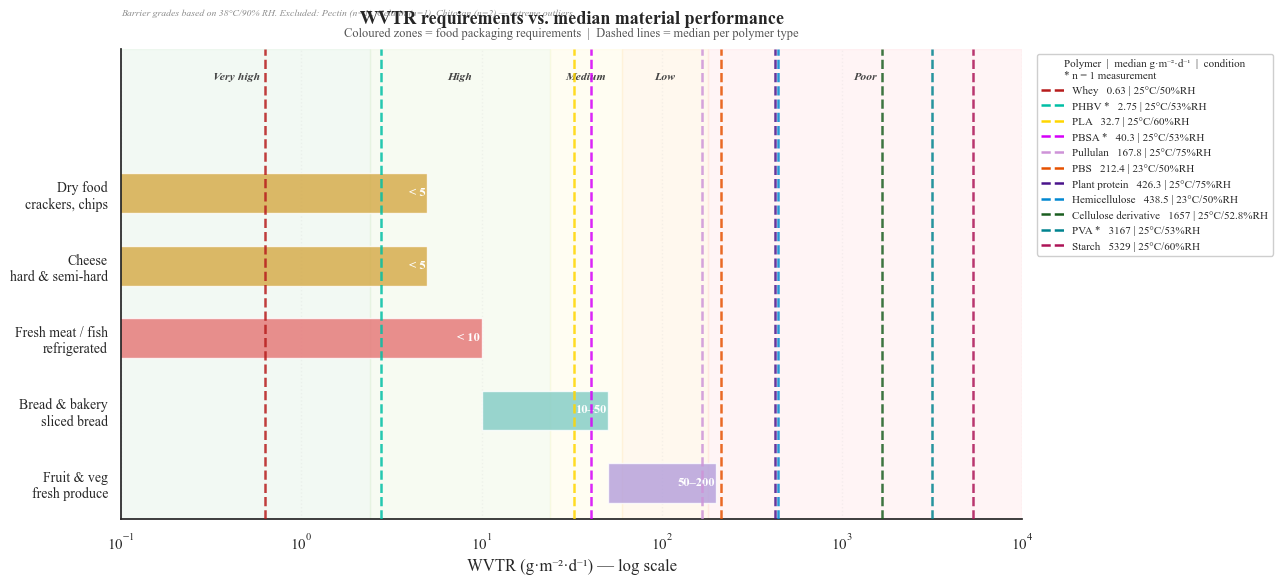

Saved: barrier_requirements_OTR.png


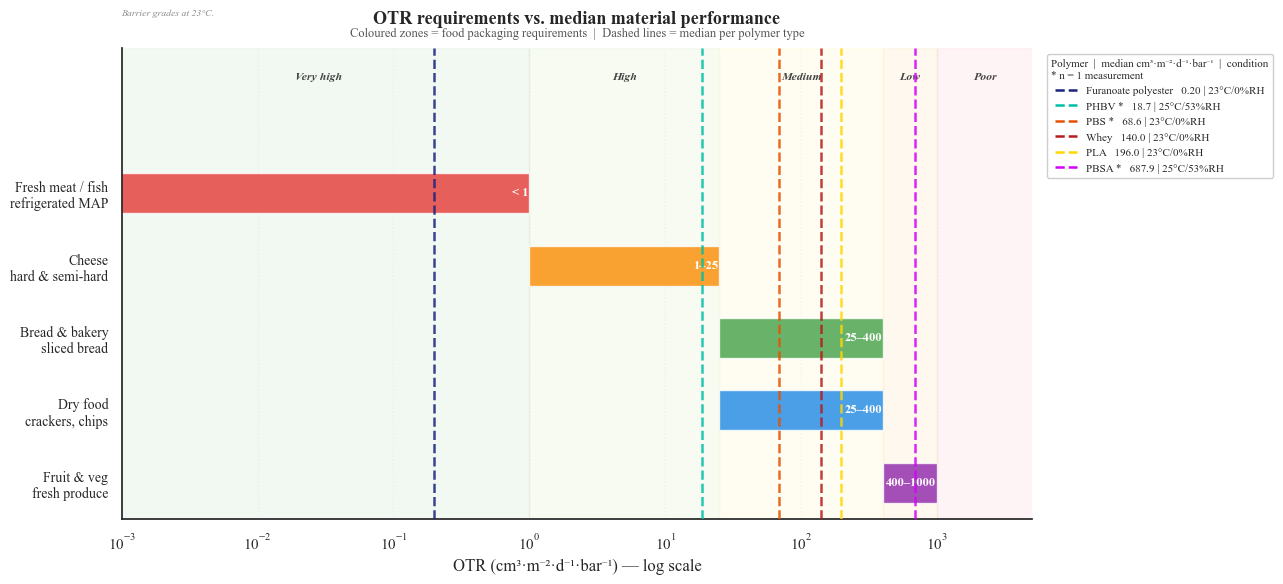

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os

# ── Load & filter ─────────────────────────────────────────────────────
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()
bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()

plt.rcParams['font.family'] = 'Times New Roman'

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

POLYMER_COLORS = {
    'Cellulose derivative': '#1B5E20',
    'Chitosan':             '#388E3C',
    'Gelatin':              '#1565C0',
    'Hemicellulose':        '#0288D1',
    'PBS':                  '#E65100',
    'PBSA':                 '#D500F9',
    'PHBV':                 '#00BFA5',
    'PLA':                  '#FFD600',
    'PVA':                  '#00838F',
    'Pectin':               '#006064',
    'Plant protein':        '#4A148C',
    'Pullulan':             '#CE93D8',
    'Starch':               '#AD1457',
    'Whey':                 '#B71C1C',
    'Furanoate polyester':  '#1A237E',
}

WVTR_EXCLUDE = ['Pectin', 'Gelatin', 'Chitosan']

OTR_GRADES = [
    ('Very high', 0,    1,    '#C8E6C9'),
    ('High',      1,    25,   '#DCEDC8'),
    ('Medium',    25,   400,  '#FFF9C4'),
    ('Low',       400,  1000, '#FFE0B2'),
    ('Poor',      1000, 5e3,  '#FFCDD2'),
]

WVTR_GRADES = [
    ('Very high', 0,    2.4,  '#C8E6C9'),
    ('High',      2.4,  24,   '#DCEDC8'),
    ('Medium',    24,   60,   '#FFF9C4'),
    ('Low',       60,   180,  '#FFE0B2'),
    ('Poor',      180,  1e5,  '#FFCDD2'),
]

PRODUCTS_WVTR = [
    ('Dry food',          'crackers, chips',  0,   5,    '#D4A843'),
    ('Cheese',            'hard & semi-hard', 0,   5,    '#D4A843'),
    ('Fresh meat / fish', 'refrigerated',     0,   10,   '#E57373'),
    ('Bread & bakery',    'sliced bread',     10,  50,   '#80CBC4'),
    ('Fruit & veg',       'fresh produce',    50,  200,  '#B39DDB'),
]

PRODUCTS_OTR = [
    ('Fresh meat / fish', 'refrigerated MAP', 0,   1,    '#E53935'),
    ('Cheese',            'hard & semi-hard', 1,   25,   '#FB8C00'),
    ('Bread & bakery',    'sliced bread',     25,  400,  '#43A047'),
    ('Dry food',          'crackers, chips',  25,  400,  '#1E88E5'),
    ('Fruit & veg',       'fresh produce',    400, 1000, '#8E24AA'),
]


def fmt_cond(t, rh):
    t_s  = str(int(t))  if t  == int(t)  else str(round(t, 1))
    rh_s = str(int(rh)) if rh == int(rh) else str(round(rh, 1))
    return f"{t_s}°C/{rh_s}%RH"

def fmt_med(v):
    if v >= 1000:  return f'{v:.0f}'
    elif v >= 10:  return f'{v:.1f}'
    elif v >= 0.1: return f'{v:.2f}'
    else:          return f'{v:.3f}'


def make_figure(prop_label, unit, bio_col, bio_t_col, bio_rh_col,
                grade_zones, products, x_min, x_max, fname,
                exclude=None, grade_note=''):

    bio_sub = bio[[bio_col, bio_t_col, bio_rh_col, 'Polymer_type']].dropna()
    if exclude:
        bio_sub = bio_sub[~bio_sub['Polymer_type'].isin(exclude)]

    medians = bio_sub.groupby('Polymer_type')[bio_col].median().sort_values()

    cond_per_polymer = {}
    for ptype in medians.index:
        sub      = bio_sub[bio_sub['Polymer_type'] == ptype]
        dominant = sub.groupby([bio_t_col, bio_rh_col]).size().idxmax()
        cond_per_polymer[ptype] = fmt_cond(*dominant)

    n_products = len(products)
    fig, ax    = plt.subplots(figsize=(13, 6))

    # ── Barrier grade background ──────────────────────────────────────
    for grade, lo, hi, color in grade_zones:
        lo_c = max(lo, x_min * 0.5) if lo > 0 else x_min * 0.8
        hi_c = min(hi, x_max)
        if lo_c >= hi_c:
            continue
        ax.axvspan(lo_c, hi_c, alpha=0.22, color=color, zorder=0)
        mid = np.sqrt(lo_c * hi_c)
        if x_min <= mid <= x_max:
            ax.text(mid, n_products + 0.55, grade,
                    ha='center', va='bottom', fontsize=8.5,
                    color='#444444', fontstyle='italic', fontweight='bold')

    # ── Product zones ─────────────────────────────────────────────────
    for i, (label, sublabel, lo, hi, color) in enumerate(products):
        y    = n_products - 1 - i
        lo_c = max(lo, x_min * 0.8) if lo > 0 else x_min * 0.8
        hi_c = min(hi, x_max * 0.98)
        ax.barh(y, hi_c - lo_c, left=lo_c, height=0.55,
                color=color, alpha=0.80, zorder=1)
        range_str = f'< {hi}' if lo == 0 else f'{lo}–{hi}'
        ax.text(hi_c * 0.98, y, range_str,
                va='center', ha='right', fontsize=9,
                color='white', fontweight='bold')

    # ── Polymer median lines ──────────────────────────────────────────
    for ptype, med in medians.items():
        color = POLYMER_COLORS.get(ptype, 'grey')
        ax.axvline(med, color=color, lw=1.8, ls='--', alpha=0.85, zorder=3)

    # ── Axes ──────────────────────────────────────────────────────────
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.5, n_products + 1.0)
    ax.set_yticks(range(n_products))
    ax.set_yticklabels(
        [f'{p[0]}\n{p[1]}' for p in reversed(products)],
        fontsize=10
    )
    ax.set_xlabel(f'{prop_label} ({unit}) — log scale', fontsize=12)

    # ── Title ─────────────────────────────────────────────────────────
    ax.set_title(
        f'{prop_label} requirements vs. median material performance',
        fontsize=13, fontweight='bold', pad=18
    )
    ax.text(0.5, 1.02,
            'Coloured zones = food packaging requirements  |  Dashed lines = median per polymer type',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, color='#555555')

    if grade_note:
        ax.text(0.0, 1.065, grade_note, transform=ax.transAxes,
                fontsize=7, color='#888888', fontstyle='italic', va='bottom')

    ax.grid(axis='x', alpha=0.2, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────
    n_single = bio_sub.groupby('Polymer_type').size()
    legend_handles = []
    for ptype, med in medians.items():
        color = POLYMER_COLORS.get(ptype, 'grey')
        cond  = cond_per_polymer[ptype]
        n     = n_single.get(ptype, 0)
        note  = ' *' if n == 1 else ''
        label = f'{ptype}{note}   {fmt_med(med)} | {cond}'
        legend_handles.append(
            mlines.Line2D([], [], color=color, lw=1.8, ls='--', label=label)
        )

    ax.legend(
        handles=legend_handles,
        fontsize=8,
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        frameon=True,
        framealpha=0.95,
        title=f'Polymer  |  median {unit}  |  condition\n* n = 1 measurement',
        title_fontsize=8
    )

    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, fname),
                dpi=300, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()


# ── WVTR ─────────────────────────────────────────────────────────────
make_figure(
    prop_label='WVTR',
    unit='g·m⁻²·d⁻¹',
    bio_col='WVTR100_g·m-2·d-1 ',
    bio_t_col='WVTR_temperature_°C',
    bio_rh_col='WVTR_RH_%',
    grade_zones=WVTR_GRADES,
    products=PRODUCTS_WVTR,
    x_min=0.1,
    x_max=1e4,
    fname='barrier_requirements_WVTR.png',
    exclude=WVTR_EXCLUDE,
    grade_note=(
        'Barrier grades based on 38°C/90% RH. '
        'Excluded: Pectin (n=1), Gelatin (n=1), Chitosan (n=2) — extreme outliers.'
    )
)

# ── OTR ──────────────────────────────────────────────────────────────
make_figure(
    prop_label='OTR',
    unit='cm³·m⁻²·d⁻¹·bar⁻¹',
    bio_col='OTR100_cm3·m-2·d-1·bar-1',
    bio_t_col='OTR_temperature_°C',
    bio_rh_col='OTR_RH_%',
    grade_zones=OTR_GRADES,
    products=PRODUCTS_OTR,
    x_min=0.001,
    x_max=5e3,
    fname='barrier_requirements_OTR.png',
    grade_note='Barrier grades at 23°C.'
)

Saved: barrier_requirements_WVTR.png


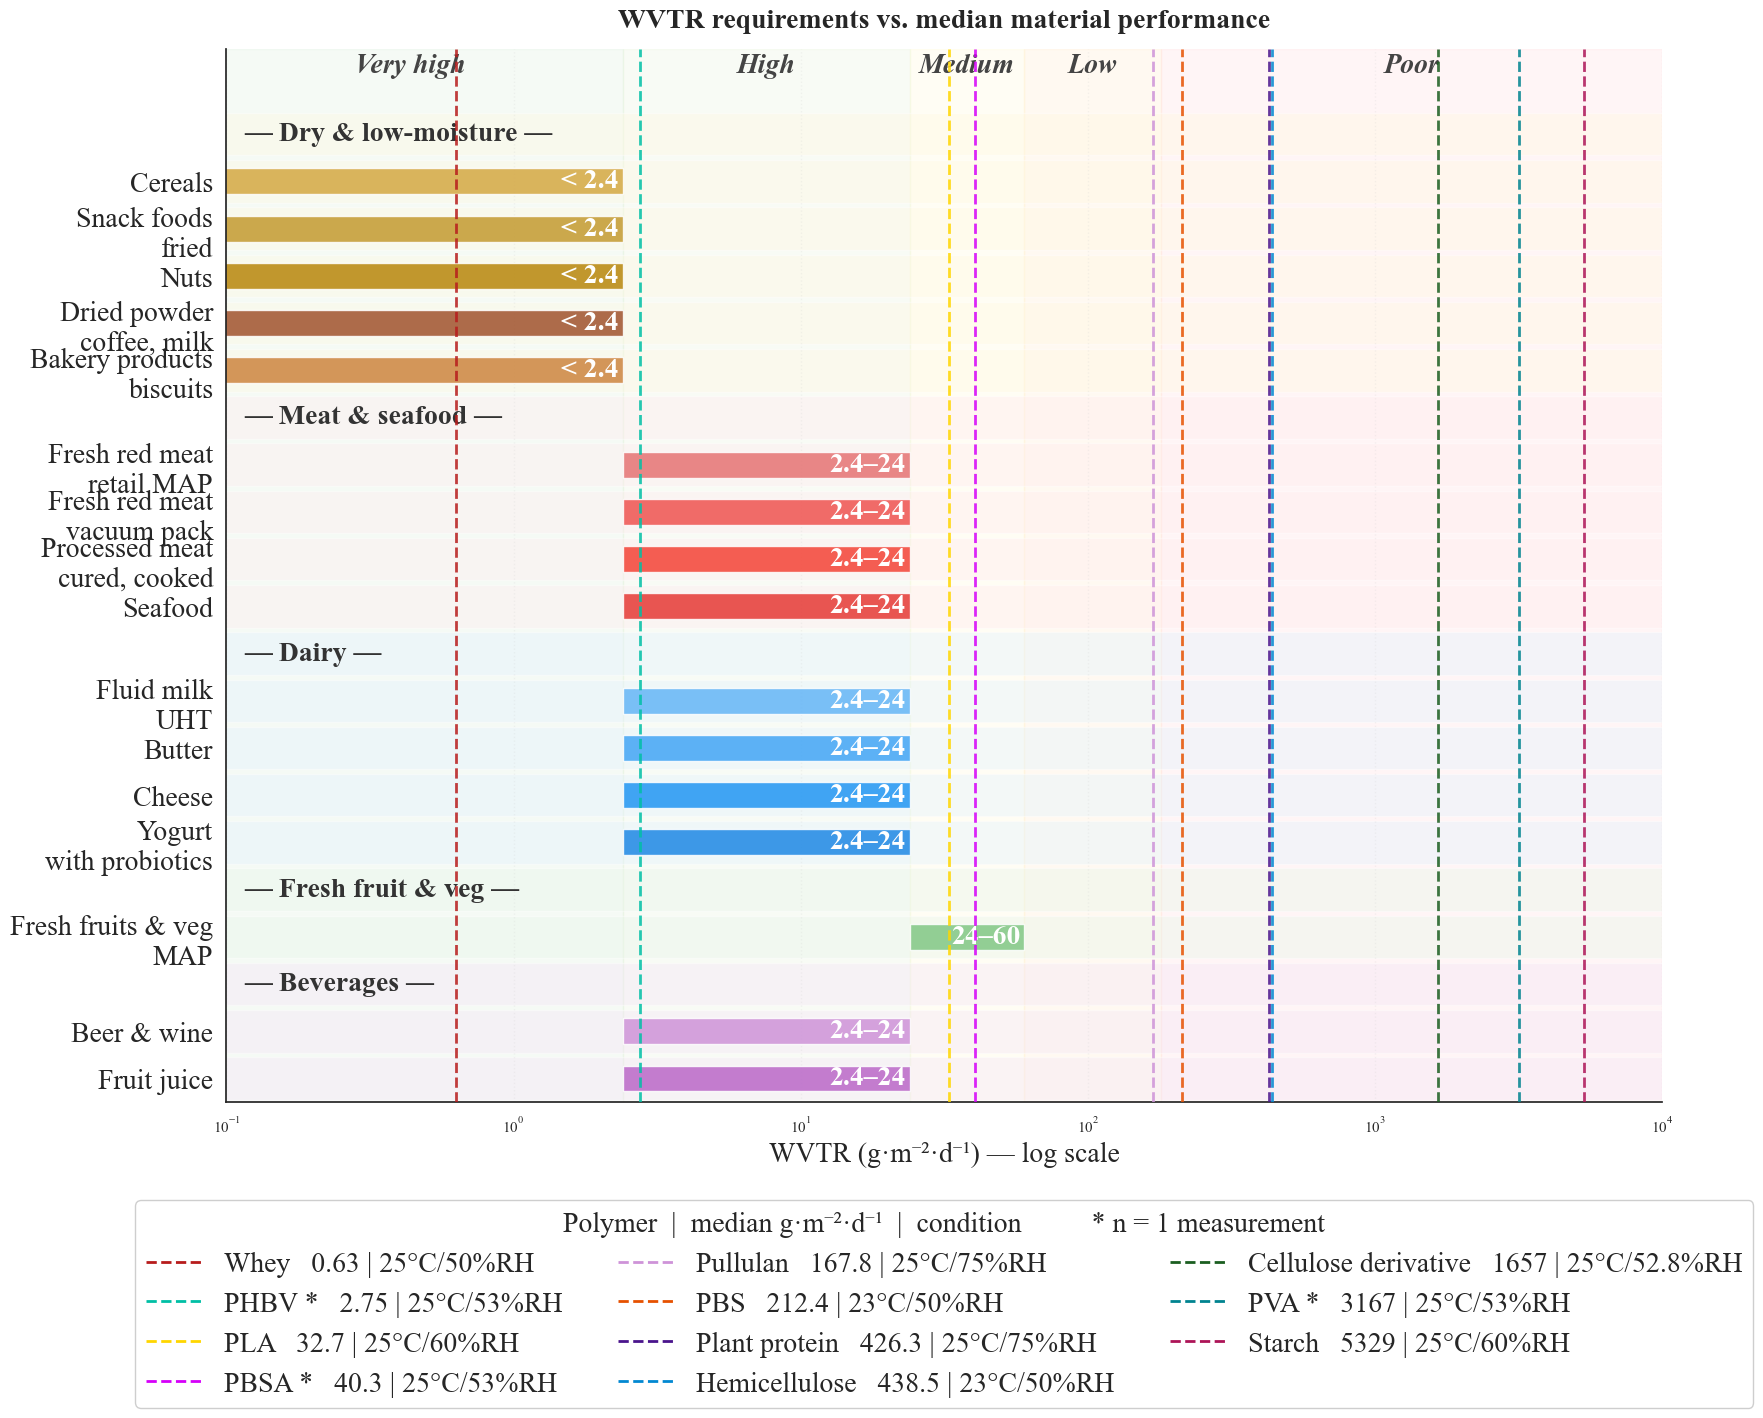

Saved: barrier_requirements_OTR.png


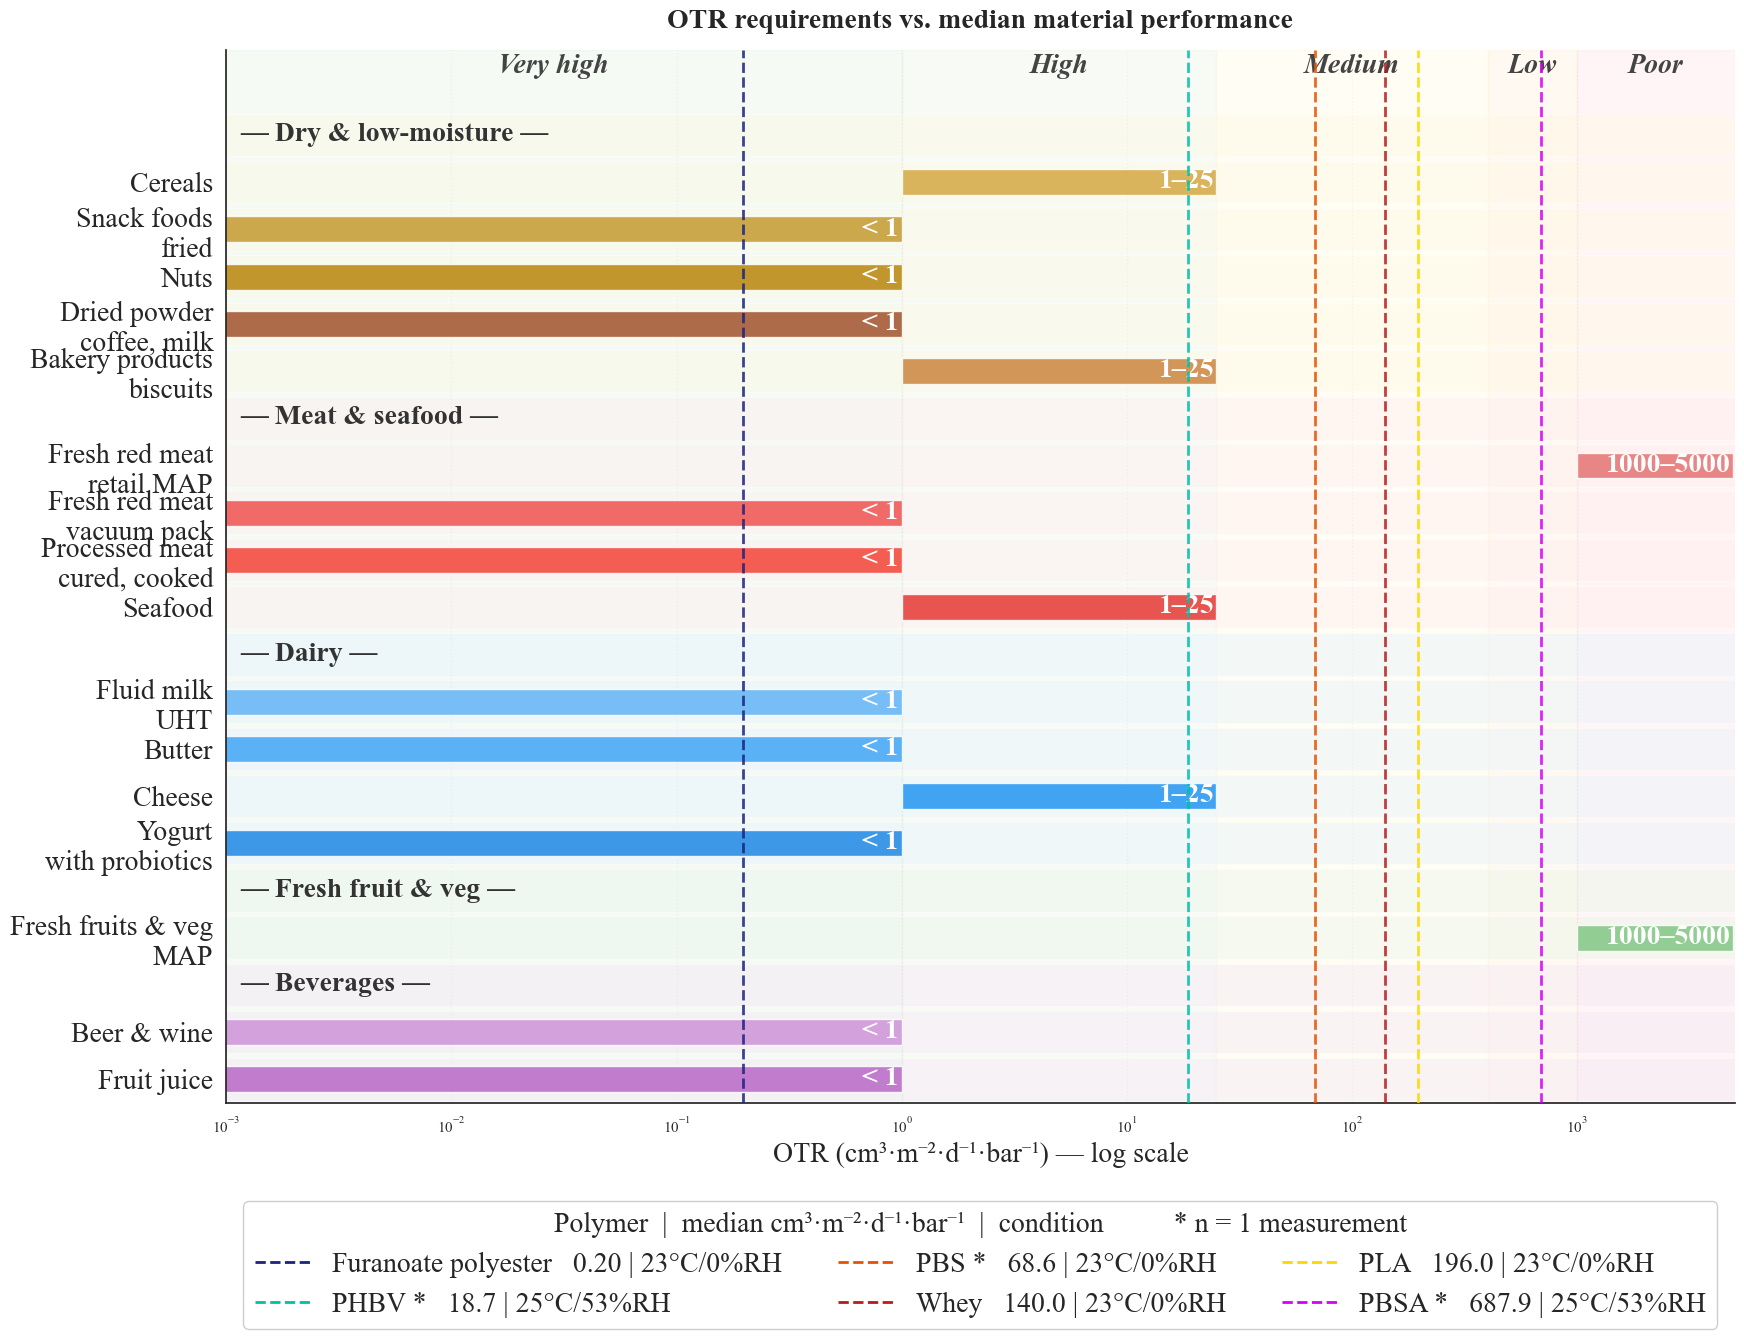

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os

# ── Load & filter ─────────────────────────────────────────────────────
file_name = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'
df = pd.read_excel(file_name, sheet_name='Data')
df = df[df['Included_after_screening'] == 'Yes'].copy()
bio = df[(df['Biobased'] == 'Yes') | (df['Biodegradable'] == 'Yes')].copy()

plt.rcParams['font.family'] = 'Times New Roman'

output_folder = 'visualizations_v7'
os.makedirs(output_folder, exist_ok=True)

POLYMER_COLORS = {
    'Cellulose derivative': '#1B5E20',
    'Chitosan':             '#388E3C',
    'Gelatin':              '#1565C0',
    'Hemicellulose':        '#0288D1',
    'PBS':                  '#E65100',
    'PBSA':                 '#D500F9',
    'PHBV':                 '#00BFA5',
    'PLA':                  '#FFD600',
    'PVA':                  '#00838F',
    'Pectin':               '#006064',
    'Plant protein':        '#4A148C',
    'Pullulan':             '#CE93D8',
    'Starch':               '#AD1457',
    'Whey':                 '#B71C1C',
    'Furanoate polyester':  '#1A237E',
}

WVTR_EXCLUDE = ['Pectin', 'Gelatin', 'Chitosan']

OTR_GRADES = [
    ('Very high', 0,    1,    '#C8E6C9'),
    ('High',      1,    25,   '#DCEDC8'),
    ('Medium',    25,   400,  '#FFF9C4'),
    ('Low',       400,  1000, '#FFE0B2'),
    ('Poor',      1000, 5e3,  '#FFCDD2'),
]

WVTR_GRADES = [
    ('Very high', 0,    2.4,  '#C8E6C9'),
    ('High',      2.4,  24,   '#DCEDC8'),
    ('Medium',    24,   60,   '#FFF9C4'),
    ('Low',       60,   180,  '#FFE0B2'),
    ('Poor',      180,  1e4,  '#FFCDD2'),
]

PRODUCTS = [
    ('Dry & low-moisture', 'Cereals',           '',                0,    2.4,  1,    25,   '#D4A843'),
    ('Dry & low-moisture', 'Snack foods',       'fried',           0,    2.4,  0,    1,    '#C49A30'),
    ('Dry & low-moisture', 'Nuts',              '',                0,    2.4,  0,    1,    '#B8860B'),
    ('Dry & low-moisture', 'Dried powder',      'coffee, milk',    0,    2.4,  0,    1,    '#A0522D'),
    ('Dry & low-moisture', 'Bakery products',   'biscuits',        0,    2.4,  1,    25,   '#CD853F'),
    ('Meat & seafood',     'Fresh red meat',    'retail MAP',      2.4,  24,   1000, 5000, '#E57373'),
    ('Meat & seafood',     'Fresh red meat',    'vacuum pack',     2.4,  24,   0,    1,    '#EF5350'),
    ('Meat & seafood',     'Processed meat',    'cured, cooked',   2.4,  24,   0,    1,    '#F44336'),
    ('Meat & seafood',     'Seafood',           '',                2.4,  24,   1,    25,   '#E53935'),
    ('Dairy',              'Fluid milk',        'UHT',             2.4,  24,   0,    1,    '#64B5F6'),
    ('Dairy',              'Butter',            '',                2.4,  24,   0,    1,    '#42A5F5'),
    ('Dairy',              'Cheese',            '',                2.4,  24,   1,    25,   '#2196F3'),
    ('Dairy',              'Yogurt',            'with probiotics', 2.4,  24,   0,    1,    '#1E88E5'),
    ('Fresh fruit & veg',  'Fresh fruits & veg','MAP',             24,   60,   1000, 5000, '#81C784'),
    ('Beverages',          'Beer & wine',       '',                2.4,  24,   0,    1,    '#CE93D8'),
    ('Beverages',          'Fruit juice',       '',                2.4,  24,   0,    1,    '#BA68C8'),
]

GROUPS = [
    ('Dry & low-moisture', '#FFF8E1'),
    ('Meat & seafood',     '#FFEBEE'),
    ('Dairy',              '#E3F2FD'),
    ('Fresh fruit & veg',  '#E8F5E9'),
    ('Beverages',          '#F3E5F5'),
]


def fmt_cond(t, rh):
    t_s  = str(int(t))  if t  == int(t)  else str(round(t, 1))
    rh_s = str(int(rh)) if rh == int(rh) else str(round(rh, 1))
    return f"{t_s}°C/{rh_s}%RH"

def fmt_med(v):
    if v >= 1000:  return f'{v:.0f}'
    elif v >= 10:  return f'{v:.1f}'
    elif v >= 0.1: return f'{v:.2f}'
    else:          return f'{v:.3f}'


def make_figure(prop_label, unit, bio_col, bio_t_col, bio_rh_col,
                grade_zones, lo_key,
                x_min, x_max, fname, exclude=None, grade_note=''):

    bio_sub = bio[[bio_col, bio_t_col, bio_rh_col, 'Polymer_type']].dropna()
    if exclude:
        bio_sub = bio_sub[~bio_sub['Polymer_type'].isin(exclude)]

    medians = bio_sub.groupby('Polymer_type')[bio_col].median().sort_values()

    cond_per_polymer = {}
    for ptype in medians.index:
        sub      = bio_sub[bio_sub['Polymer_type'] == ptype]
        dominant = sub.groupby([bio_t_col, bio_rh_col]).size().idxmax()
        cond_per_polymer[ptype] = fmt_cond(*dominant)

    group_bg_map = {g: c for g, c in GROUPS}

    rows = []
    current_group = None
    for group, label, sublabel, wvtr_lo, wvtr_hi, otr_lo, otr_hi, color in PRODUCTS:
        if group != current_group:
            bg = group_bg_map.get(group, '#EEEEEE')
            rows.append(('header', group, '', '', None, None, '#555555', bg))
            current_group = group
        lo = wvtr_lo if lo_key == 'wvtr' else otr_lo
        hi = wvtr_hi if lo_key == 'wvtr' else otr_hi
        bg = group_bg_map.get(group, '#FFFFFF')
        rows.append(('product', group, label, sublabel, lo, hi, color, bg))

    n_rows  = len(rows)
    fig_h   = max(n_rows * 0.55 + 2, 10)
    fig, ax = plt.subplots(figsize=(18, fig_h))

    # ── Barrier grade background ──────────────────────────────────────
    for grade, lo, hi, color in grade_zones:
        lo_c = max(lo, x_min * 0.5) if lo > 0 else x_min * 0.8
        hi_c = min(hi, x_max)
        if lo_c >= hi_c:
            continue
        ax.axvspan(lo_c, hi_c, alpha=0.18, color=color, zorder=0)
        mid = np.sqrt(lo_c * hi_c)
        if x_min <= mid <= x_max:
            ax.text(mid, n_rows + 0.2, grade,
                    ha='center', va='bottom', fontsize=20,
                    color='#444444', fontstyle='italic', fontweight='bold')

    # ── Rows ──────────────────────────────────────────────────────────
    ytick_pos    = []
    ytick_labels = []

    for i, row in enumerate(reversed(rows)):
        y     = i
        rtype = row[0]
        bg    = row[7]

        ax.barh(y, x_max * 10, left=x_min * 0.01, height=0.9,
                color=bg, alpha=0.4, zorder=0)

        if rtype == 'header':
            grp_label = row[1]
            ax.text(x_min * 1.15, y, f'— {grp_label} —',
                    va='center', ha='left', fontsize=20,
                    fontweight='bold', color='#333333', zorder=4)
            ytick_pos.append(y)
            ytick_labels.append('')

        else:
            _, grp, label, sublabel, lo, hi, color, _ = row
            full_label = f'{label}\n{sublabel}' if sublabel else label
            ytick_pos.append(y)
            ytick_labels.append(full_label)

            if lo is not None and hi is not None and hi > 0:
                lo_c = max(lo, x_min * 0.8) if lo > 0 else x_min * 0.8
                hi_c = min(hi, x_max * 0.98)
                if hi_c > lo_c:
                    ax.barh(y, hi_c - lo_c, left=lo_c, height=0.55,
                            color=color, alpha=0.85, zorder=2)
                    range_str = f'< {hi}' if lo == 0 else f'{lo}–{hi}'
                    ax.text(hi_c * 0.97, y, range_str,
                            va='center', ha='right', fontsize=20,
                            color='white', fontweight='bold', zorder=3)

    # ── Polymer lines ─────────────────────────────────────────────────
    for ptype, med in medians.items():
        color = POLYMER_COLORS.get(ptype, 'grey')
        ax.axvline(med, color=color, lw=2.0, ls='--', alpha=0.85, zorder=5)

    # ── Axes ──────────────────────────────────────────────────────────
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.5, n_rows + 0.8)
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels, fontsize=20)
    ax.set_xlabel(f'{prop_label} ({unit}) — log scale', fontsize=20)

    ax.set_title(
        f'{prop_label} requirements vs. median material performance',
        fontsize=20, fontweight='bold', pad=16
    )

    ax.grid(axis='x', alpha=0.2, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Legend onderaan ───────────────────────────────────────────────
    n_single = bio_sub.groupby('Polymer_type').size()
    legend_handles = []
    for ptype, med in medians.items():
        color = POLYMER_COLORS.get(ptype, 'grey')
        cond  = cond_per_polymer[ptype]
        n     = n_single.get(ptype, 0)
        note  = ' *' if n == 1 else ''
        label = f'{ptype}{note}   {fmt_med(med)} | {cond}'
        legend_handles.append(
            mlines.Line2D([], [], color=color, lw=2.0, ls='--', label=label)
        )

    ax.legend(
        handles=legend_handles,
        fontsize=20,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.08),
        frameon=True,
        framealpha=0.95,
        ncol=3,
        title=f'Polymer  |  median {unit}  |  condition          * n = 1 measurement',
        title_fontsize=20
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    plt.savefig(os.path.join(output_folder, fname),
                dpi=300, bbox_inches='tight')
    print(f"Saved: {fname}")
    plt.show()


# ── WVTR ─────────────────────────────────────────────────────────────
make_figure(
    prop_label='WVTR',
    unit='g·m⁻²·d⁻¹',
    bio_col='WVTR100_g·m-2·d-1 ',
    bio_t_col='WVTR_temperature_°C',
    bio_rh_col='WVTR_RH_%',
    grade_zones=WVTR_GRADES,
    lo_key='wvtr',
    x_min=0.1, x_max=1e4,
    fname='barrier_requirements_WVTR.png',
    exclude=WVTR_EXCLUDE,
)

# ── OTR ──────────────────────────────────────────────────────────────
make_figure(
    prop_label='OTR',
    unit='cm³·m⁻²·d⁻¹·bar⁻¹',
    bio_col='OTR100_cm3·m-2·d-1·bar-1',
    bio_t_col='OTR_temperature_°C',
    bio_rh_col='OTR_RH_%',
    grade_zones=OTR_GRADES,
    lo_key='otr',
    x_min=0.001, x_max=5e3,
    fname='barrier_requirements_OTR.png',
)